In [1]:
import datetime as dt
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import warnings
warnings.filterwarnings("ignore")

sns.set_theme(context='notebook', palette='bright')

In [2]:
ai_jobs = pd.read_csv(r"C:\it_academy\da_sprint10_proyecto\ai_job_dataset.csv")
print(ai_jobs.shape, "\n")
print(ai_jobs.columns,  "\n")
ai_jobs.info()
ai_jobs.head()

(15000, 19) 

Index(['job_id', 'job_title', 'salary_usd', 'salary_currency',
       'experience_level', 'employment_type', 'company_location',
       'company_size', 'employee_residence', 'remote_ratio', 'required_skills',
       'education_required', 'years_experience', 'industry', 'posting_date',
       'application_deadline', 'job_description_length', 'benefits_score',
       'company_name'],
      dtype='object') 

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15000 entries, 0 to 14999
Data columns (total 19 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   job_id                  15000 non-null  object 
 1   job_title               15000 non-null  object 
 2   salary_usd              15000 non-null  int64  
 3   salary_currency         15000 non-null  object 
 4   experience_level        15000 non-null  object 
 5   employment_type         15000 non-null  object 
 6   company_location        15000 non-null 

,job_id,job_title,salary_usd,salary_currency,experience_level,employment_type,company_location,company_size,employee_residence,remote_ratio,required_skills,education_required,years_experience,industry,posting_date,application_deadline,job_description_length,benefits_score,company_name
0,AI00001,AI Research Scientist,90376,USD,SE,CT,China,M,China,50,"Tableau, PyTorch, Kubernetes, Linux, NLP",Bachelor,9,Automotive,2024-10-18,2024-11-07,1076,5.9,Smart Analytics
1,AI00002,AI Software Engineer,61895,USD,EN,CT,Canada,M,Ireland,100,"Deep Learning, AWS, Mathematics, Python, Docker",Master,1,Media,2024-11-20,2025-01-11,1268,5.2,TechCorp Inc
2,AI00003,AI Specialist,152626,USD,MI,FL,Switzerland,L,South Korea,0,"Kubernetes, Deep Learning, Java, Hadoop, NLP",Associate,2,Education,2025-03-18,2025-04-07,1974,9.4,Autonomous Tech
3,AI00004,NLP Engineer,80215,USD,SE,FL,India,M,India,50,"Scala, SQL, Linux, Python",PhD,7,Consulting,2024-12-23,2025-02-24,1345,8.6,Future Systems
4,AI00005,AI Consultant,54624,EUR,EN,PT,France,S,Singapore,100,"MLOps, Java, Tableau, Python",Master,0,Media,2025-04-15,2025-06-23,1989,6.6,Advanced Robotics


In [3]:
ai_jobs.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15000 entries, 0 to 14999
Data columns (total 19 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   job_id                  15000 non-null  object 
 1   job_title               15000 non-null  object 
 2   salary_usd              15000 non-null  int64  
 3   salary_currency         15000 non-null  object 
 4   experience_level        15000 non-null  object 
 5   employment_type         15000 non-null  object 
 6   company_location        15000 non-null  object 
 7   company_size            15000 non-null  object 
 8   employee_residence      15000 non-null  object 
 9   remote_ratio            15000 non-null  int64  
 10  required_skills         15000 non-null  object 
 11  education_required      15000 non-null  object 
 12  years_experience        15000 non-null  int64  
 13  industry                15000 non-null  object 
 14  posting_date            15000 non-null

In [4]:
round(ai_jobs.describe(),3)

,salary_usd,remote_ratio,years_experience,job_description_length,benefits_score
count,15000.000,15000.000,15000.000,15000.000,15000.000
mean,115348.965,49.483,6.253,1503.315,7.504
std,60260.940,40.813,5.546,576.127,1.451
min,32519.000,0.000,0.000,500.000,5.000
25%,70179.750,0.000,2.000,1003.750,6.200
50%,99705.000,50.000,5.000,1512.000,7.500
75%,146408.500,100.000,10.000,2000.000,8.800
max,399095.000,100.000,19.000,2499.000,10.000


In [5]:
ai_jobs.describe(include='object')

,job_id,job_title,salary_currency,experience_level,employment_type,company_location,company_size,employee_residence,required_skills,education_required,industry,posting_date,application_deadline,company_name
count,15000,15000,15000,15000,15000,15000,15000,15000,15000,15000,15000,15000,15000,15000
unique,15000,20,3,4,4,20,3,20,13663,4,15,486,543,16
top,AI15000,Machine Learning Researcher,USD,MI,FT,Germany,S,Sweden,"Python, TensorFlow, PyTorch",Bachelor,Retail,2024-07-05,2025-01-05,TechCorp Inc
freq,1,808,11957,3781,3812,814,5007,790,17,3789,1063,51,47,980


In [6]:
# Elimino columnas que no me aportan informacion
ai_jobs.drop(columns={'job_description_length','salary_currency'},axis=1,inplace=True)

In [7]:
# Creo la columna job_area
ai_jobs.loc[
    ai_jobs['job_title'].isin([
        'AI Software Engineer',
        'NLP Engineer',
        'AI Architect',
        'Machine Learning Engineer',
        'Deep Learning Engineer',
        'Machine Learning Researcher',
        'Computer Vision Engineer',
        'AI Specialist'
    ]), 'job_area'] = 'AI Model Development & Engineering'
ai_jobs.loc[
    ai_jobs['job_title'].isin([
        'Principal Data Scientist', 'Data Analyst', 'Data Engineer', 'Data Scientist'
    ]), 'job_area'] = 'Data & Infrastructure'
ai_jobs.loc[
    ai_jobs['job_title'].isin(['Autonomous Systems Engineer', 'ML Ops Engineer', 'Robotics Engineer'
    ]), 'job_area'] = 'Operations & Maintenance (MLOps)'
ai_jobs.loc[
    ai_jobs['job_title'].isin(['AI Research Scientist', 'AI Consultant', 'AI Product Manager', 'Research Scientist', 'Head of AI'
    ]), 'job_area'] = 'Strategy & Business Application'

In [8]:
# Conocer los valores unicos de cada variable categorica
category_columns = ai_jobs.select_dtypes(include=object)
for column in category_columns:
    print(f"\nColumn: {column}")
    print(f"Unique values ({ai_jobs[column].nunique()}): {ai_jobs[column].unique()}")
    print("---"*30)


Column: job_id
Unique values (15000): ['AI00001' 'AI00002' 'AI00003' ... 'AI14998' 'AI14999' 'AI15000']
------------------------------------------------------------------------------------------

Column: job_title
Unique values (20): ['AI Research Scientist' 'AI Software Engineer' 'AI Specialist'
 'NLP Engineer' 'AI Consultant' 'AI Architect' 'Principal Data Scientist'
 'Data Analyst' 'Autonomous Systems Engineer' 'AI Product Manager'
 'Machine Learning Engineer' 'Data Engineer' 'Research Scientist'
 'ML Ops Engineer' 'Robotics Engineer' 'Head of AI'
 'Deep Learning Engineer' 'Data Scientist' 'Machine Learning Researcher'
 'Computer Vision Engineer']
------------------------------------------------------------------------------------------

Column: experience_level
Unique values (4): ['SE' 'EN' 'MI' 'EX']
------------------------------------------------------------------------------------------

Column: employment_type
Unique values (4): ['CT' 'FL' 'PT' 'FT']
-------------------------

Unique values (20): ['China' 'Ireland' 'South Korea' 'India' 'Singapore' 'Germany'
 'United Kingdom' 'France' 'Austria' 'Sweden' 'Norway' 'Israel'
 'United States' 'Netherlands' 'Denmark' 'Switzerland' 'Finland' 'Japan'
 'Canada' 'Australia']
------------------------------------------------------------------------------------------

Column: required_skills
Unique values (13663): ['Tableau, PyTorch, Kubernetes, Linux, NLP'
 'Deep Learning, AWS, Mathematics, Python, Docker'
 'Kubernetes, Deep Learning, Java, Hadoop, NLP' ... 'Scala, Spark, NLP'
 'Java, Computer Vision, Python, TensorFlow'
 'Scala, Azure, Deep Learning, GCP, Mathematics']
------------------------------------------------------------------------------------------

Column: education_required
Unique values (4): ['Bachelor' 'Master' 'Associate' 'PhD']
------------------------------------------------------------------------------------------

Column: industry
Unique values (15): ['Automotive' 'Media' 'Education' 'Consulting' 'H

In [9]:
### Reemplazo las siglas por palabra completa para que se entienda mejor
ai_jobs['experience_level'].replace({'SE':'Senior','EN':'Entry','MI':'Mid','EX':'Executive'},inplace=True)
ai_jobs['employment_type'].replace({'CT':'Contract','FL':'Freelance','PT':'Part-Time','FT':'Full-Time'},inplace=True)
ai_jobs['company_size'].replace({'M':'Medium','L':'Large','S':'Small'},inplace=True)

In [10]:
ai_jobs.rename(columns={'remote_ratio':'work_format'},inplace=True)
ai_jobs['work_format'].replace({0:'Onsite',50:'Hybrid',100:'Remote'},inplace=True)

In [11]:
ai_jobs.head(3)

,job_id,job_title,salary_usd,experience_level,employment_type,company_location,company_size,employee_residence,work_format,required_skills,education_required,years_experience,industry,posting_date,application_deadline,benefits_score,company_name,job_area
0,AI00001,AI Research Scientist,90376,Senior,Contract,China,Medium,China,Hybrid,"Tableau, PyTorch, Kubernetes, Linux, NLP",Bachelor,9,Automotive,2024-10-18,2024-11-07,5.9,Smart Analytics,Strategy & Business Application
1,AI00002,AI Software Engineer,61895,Entry,Contract,Canada,Medium,Ireland,Remote,"Deep Learning, AWS, Mathematics, Python, Docker",Master,1,Media,2024-11-20,2025-01-11,5.2,TechCorp Inc,AI Model Development & Engineering
2,AI00003,AI Specialist,152626,Mid,Freelance,Switzerland,Large,South Korea,Onsite,"Kubernetes, Deep Learning, Java, Hadoop, NLP",Associate,2,Education,2025-03-18,2025-04-07,9.4,Autonomous Tech,AI Model Development & Engineering


In [12]:
# Convierto el tipo de dato de estas columnas de object a datetime
ai_jobs['application_deadline'] = pd.to_datetime(ai_jobs['application_deadline'])
ai_jobs['posting_date'] = pd.to_datetime(ai_jobs['posting_date'])
ai_jobs[['application_deadline','posting_date']].info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15000 entries, 0 to 14999
Data columns (total 2 columns):
 #   Column                Non-Null Count  Dtype         
---  ------                --------------  -----         
 0   application_deadline  15000 non-null  datetime64[ns]
 1   posting_date          15000 non-null  datetime64[ns]
dtypes: datetime64[ns](2)
memory usage: 234.5 KB


In [13]:
# Creo columnas mes, año, trimestre y dia de la semana
ai_jobs['posting_month']=ai_jobs['posting_date'].dt.month  #mes
ai_jobs['posting_year']=ai_jobs['posting_date'].dt.year    #año
ai_jobs['posting_quarter'] = ai_jobs['posting_date'].dt.quarter   #trimestre


In [14]:
ai_jobs.head(3)
ai_jobs.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15000 entries, 0 to 14999
Data columns (total 21 columns):
 #   Column                Non-Null Count  Dtype         
---  ------                --------------  -----         
 0   job_id                15000 non-null  object        
 1   job_title             15000 non-null  object        
 2   salary_usd            15000 non-null  int64         
 3   experience_level      15000 non-null  object        
 4   employment_type       15000 non-null  object        
 5   company_location      15000 non-null  object        
 6   company_size          15000 non-null  object        
 7   employee_residence    15000 non-null  object        
 8   work_format           15000 non-null  object        
 9   required_skills       15000 non-null  object        
 10  education_required    15000 non-null  object        
 11  years_experience      15000 non-null  int64         
 12  industry              15000 non-null  object        
 13  posting_date    

In [15]:
ai_jobs['month_year'] = ai_jobs['posting_date'].dt.to_period('M').dt.to_timestamp()
print(ai_jobs['month_year'].unique())

<DatetimeArray>
['2024-10-01 00:00:00', '2024-11-01 00:00:00', '2025-03-01 00:00:00',
 '2024-12-01 00:00:00', '2025-04-01 00:00:00', '2024-08-01 00:00:00',
 '2024-06-01 00:00:00', '2025-01-01 00:00:00', '2024-07-01 00:00:00',
 '2024-02-01 00:00:00', '2024-09-01 00:00:00', '2025-02-01 00:00:00',
 '2024-04-01 00:00:00', '2024-05-01 00:00:00', '2024-01-01 00:00:00',
 '2024-03-01 00:00:00']
Length: 16, dtype: datetime64[ns]


In [16]:
# Crear una columna que combine año y trimestre para ordenar
ai_jobs['year_quarter'] = ai_jobs['posting_date'].dt.to_period('Q').dt.to_timestamp()
print(ai_jobs['year_quarter'].unique())

<DatetimeArray>
['2024-10-01 00:00:00', '2025-01-01 00:00:00', '2025-04-01 00:00:00',
 '2024-07-01 00:00:00', '2024-04-01 00:00:00', '2024-01-01 00:00:00']
Length: 6, dtype: datetime64[ns]


In [17]:
ai_jobs.head(3)

,job_id,job_title,salary_usd,experience_level,employment_type,company_location,company_size,employee_residence,work_format,required_skills,...,posting_date,application_deadline,benefits_score,company_name,job_area,posting_month,posting_year,posting_quarter,month_year,year_quarter
0,AI00001,AI Research Scientist,90376,Senior,Contract,China,Medium,China,Hybrid,"Tableau, PyTorch, Kubernetes, Linux, NLP",...,2024-10-18,2024-11-07,5.9,Smart Analytics,Strategy & Business Application,10,2024,4,2024-10-01,2024-10-01
1,AI00002,AI Software Engineer,61895,Entry,Contract,Canada,Medium,Ireland,Remote,"Deep Learning, AWS, Mathematics, Python, Docker",...,2024-11-20,2025-01-11,5.2,TechCorp Inc,AI Model Development & Engineering,11,2024,4,2024-11-01,2024-10-01
2,AI00003,AI Specialist,152626,Mid,Freelance,Switzerland,Large,South Korea,Onsite,"Kubernetes, Deep Learning, Java, Hadoop, NLP",...,2025-03-18,2025-04-07,9.4,Autonomous Tech,AI Model Development & Engineering,3,2025,1,2025-03-01,2025-01-01


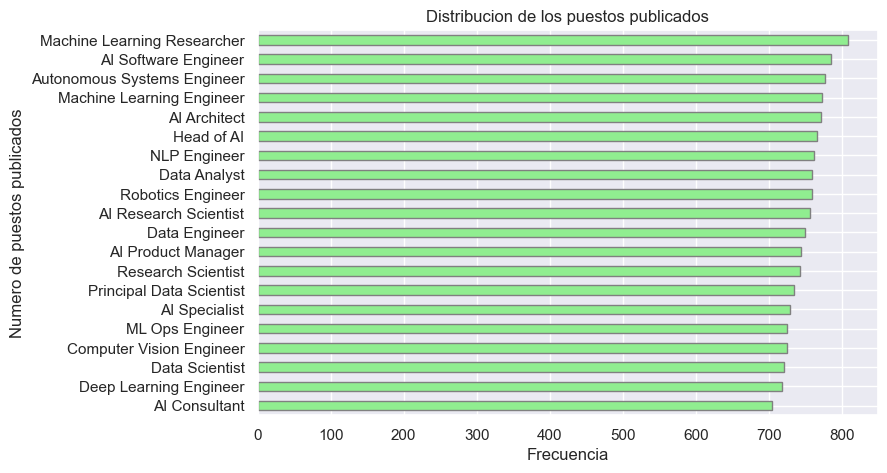

In [18]:
# Frecuencia en que se ha publicado la demanda de cada empleo típico

#colors = sns.color_palette("colorblind", n_colors=20)
ai_jobs['job_title'].value_counts(ascending=True).plot.barh(figsize=(8,5), color='lightgreen', edgecolor='gray')

plt.title("Distribucion de los puestos publicados")
plt.xlabel("Frecuencia")
plt.ylabel("Numero de puestos publicados")
plt.show()

In [19]:
# EN `POWER BI POR UN TREEMAP DE POWER BI CON DEGRADADO Y PORCENTAJES
# Para plotly, es mejor tener los datos en un DataFrame con columnas nombradas

df_treemap = ai_jobs['job_title'].value_counts().reset_index()
df_treemap.columns = ['job_title', 'count']

fig = px.treemap(df_treemap,
path=[px.Constant("AI Jobs"), 'job_title'], # Define la jerarquía. "AI Jobs" es la raíz.
values='count',
color='count', # Colorear por la cantidad de puestos
color_continuous_scale='purples', # Escala de color degradado
title='AI Jobs Treemap',
height=500)

fig.update_layout(margin = dict(t=50, l=25, r=25, b=25)) # Ajustar márgenes
fig.show()

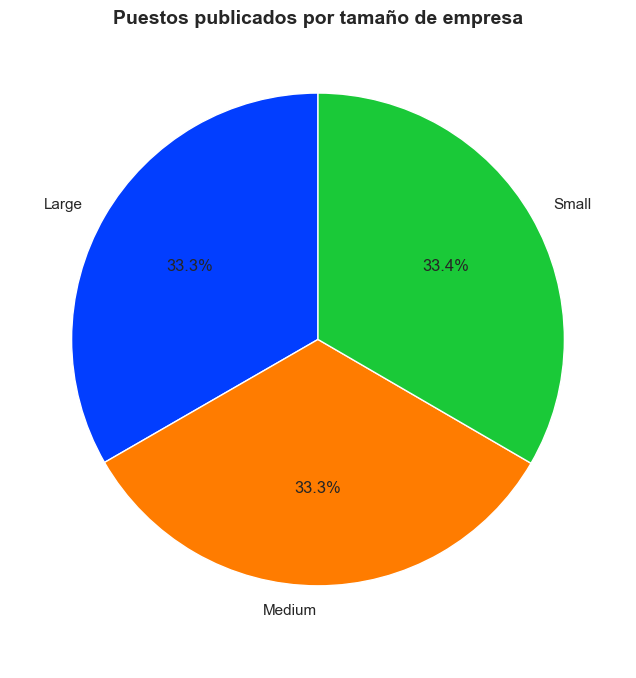

In [20]:
# Cuantos puestos han sido publicados por empresas grandes, medianas y pequeñas
colors = sns.color_palette('colorblind')
ai_jobs.groupby('company_size')['job_title'].count().plot.pie(autopct='%1.1f%%',  # Mostrar porcentajes
                        color=colors,
                        figsize=(8, 8),
                        startangle = 90)

#plt.xticks(rotation=0)

plt.title('Puestos publicados por tamaño de empresa', fontsize=14, fontweight='bold')
plt.xlabel(' ')
plt.ylabel('')
plt.show()

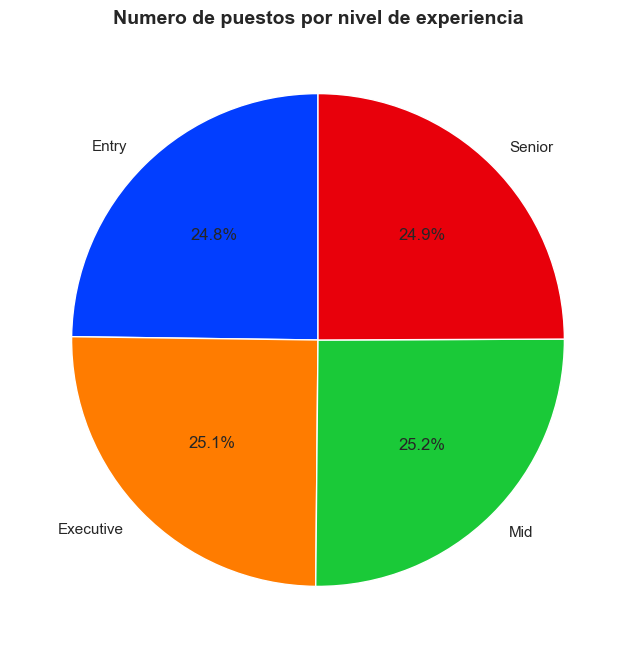

In [21]:
# Numero de puestos publicados por nivel de experiencia
colors = sns.color_palette('muted6')
ai_jobs.groupby('experience_level')['job_title'].count().plot.pie(autopct='%1.1f%%',  # Mostrar porcentajes
                        color=colors,
                        figsize=(8, 8),
                        startangle = 90)

plt.title('Numero de puestos por nivel de experiencia', fontsize=14, fontweight='bold')
plt.xlabel('')
plt.ylabel('')
plt.show()


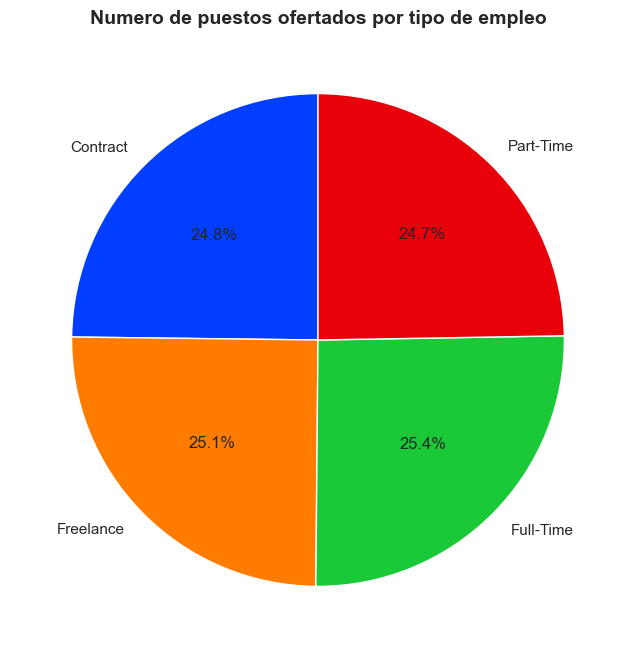

In [22]:
# Numero de puestos publcados para tipo de contratacion
colors = sns.color_palette()
ai_jobs.groupby('employment_type')['job_title'].count().plot.pie(autopct='%1.1f%%',  # Mostrar porcentajes
                        color=colors,
                        figsize=(8, 8),
                        startangle = 90)

plt.title('Numero de puestos ofertados por tipo de empleo', fontsize=14, fontweight='bold')
plt.xlabel('')
plt.ylabel('')
plt.show()

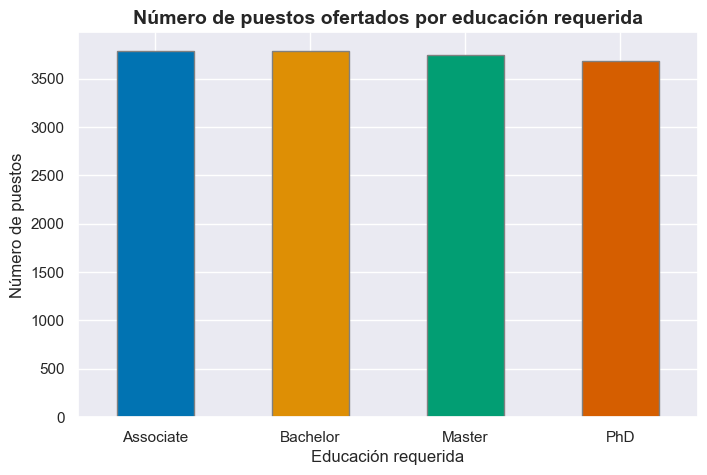

In [23]:
# Numero de puestos publcados por el nivel de educacion requerido
colors = sns.color_palette('colorblind')
ai_jobs.groupby('education_required')['job_title'].count().plot.bar(figsize=(8,5), color=colors, edgecolor='gray')

plt.xticks(rotation=0)

plt.title('Número de puestos ofertados por educación requerida', fontsize=14, fontweight='bold')
plt.xlabel('Educación requerida')
plt.ylabel('Número de puestos')
plt.show()

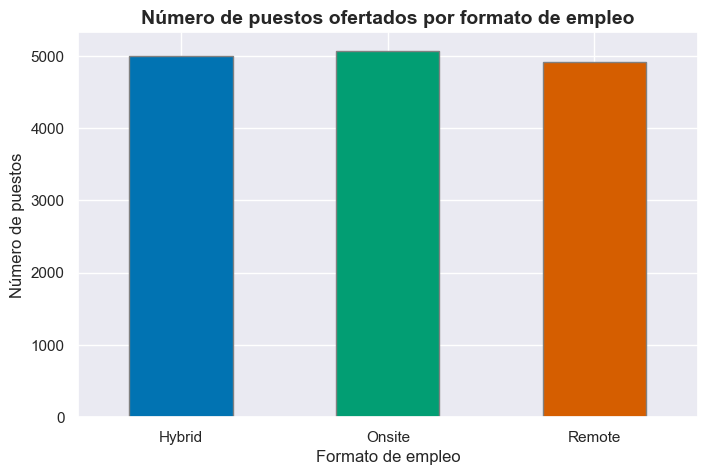

In [24]:
# Numero de puestos publcados por formato de empleo
colors = sns.color_palette('colorblind6')
ai_jobs.groupby('work_format')['job_title'].count().plot.bar(figsize=(8,5), color=colors, edgecolor='gray')

plt.xticks(rotation=0)

plt.title('Número de puestos ofertados por formato de empleo', fontsize=14, fontweight='bold')
plt.xlabel('Formato de empleo')
plt.ylabel('Número de puestos')
plt.show()

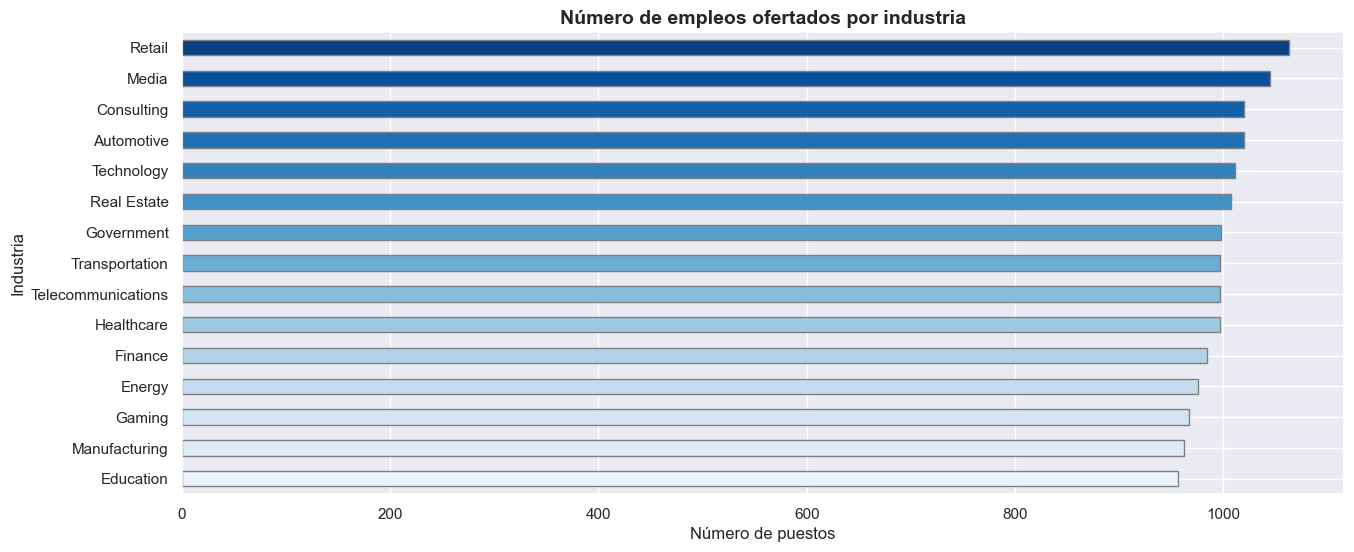

In [25]:
# Numero de puestos publicados por industria
colors = sns.color_palette('Blues', n_colors=15)
ai_jobs.groupby('industry')['job_title'].count().sort_values(ascending=True).plot.barh(figsize=(15,6), color=colors, edgecolor='gray')

plt.title('Número de empleos ofertados por industria', fontsize=14, fontweight='bold')
plt.xlabel('Número de puestos')
plt.ylabel('Industria')
plt.show()

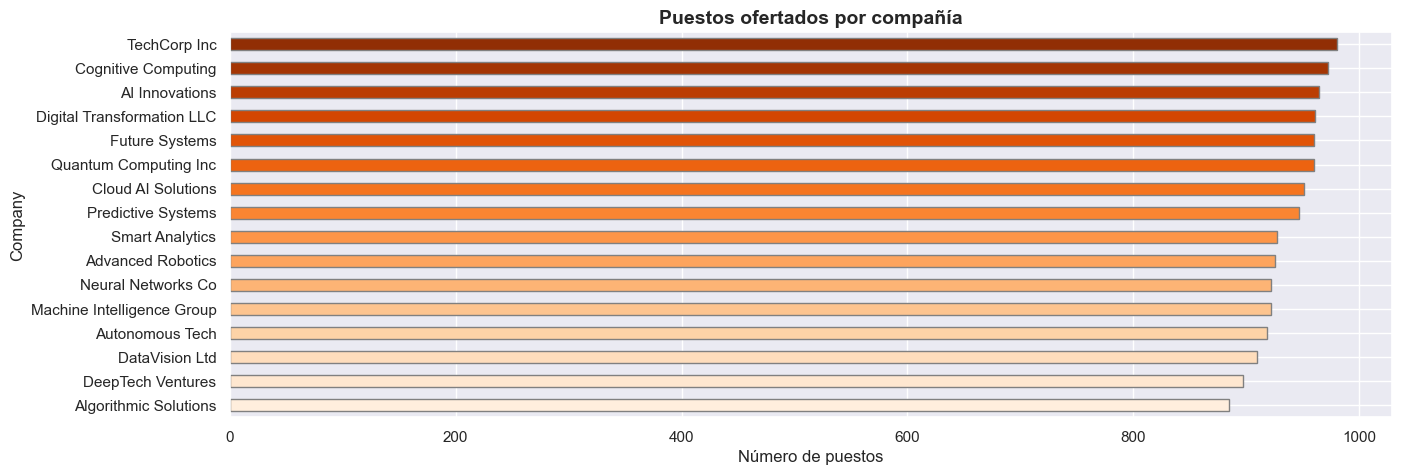

In [26]:
# Numero de puestos publicados por compañia
colors = sns.color_palette('Oranges', n_colors=16)
ai_jobs.groupby('company_name')['job_title'].count().sort_values(ascending=True).plot.barh(
	figsize=(15,5), color=colors, edgecolor='gray'
)

plt.title('Puestos ofertados por compañía',fontsize=14, fontweight='bold')
plt.xlabel('Número de puestos')
plt.ylabel('Company')
plt.show()

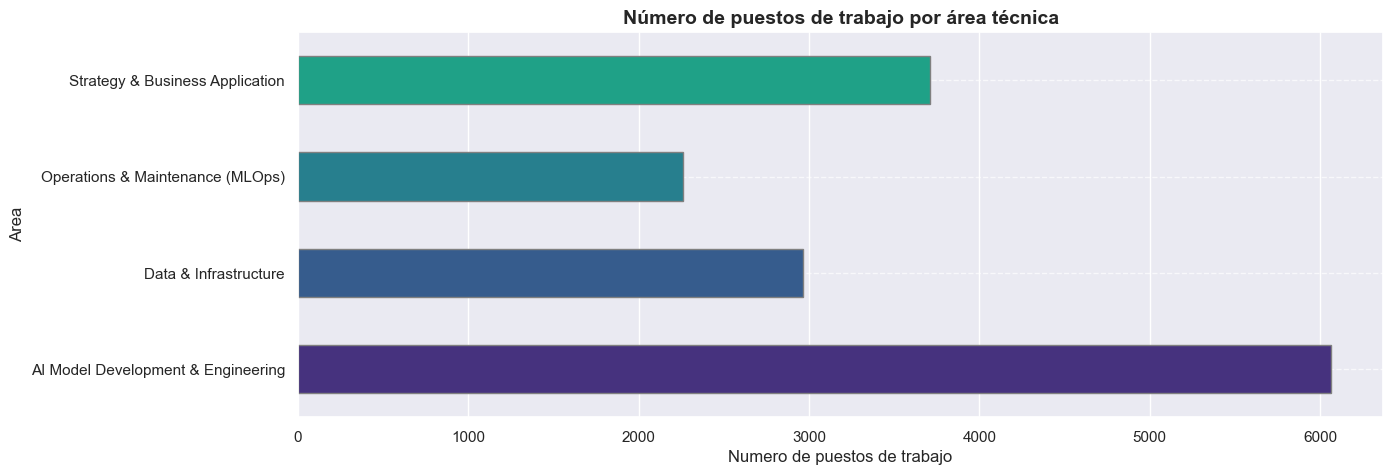

In [27]:
# Cuantos puestos de trabajo se han publicado por Area de Trabajo
colors = sns.color_palette('viridis')
ai_jobs.groupby('job_area')['job_title'].count().plot.barh(figsize=(14,5), color=colors, edgecolor='gray')

plt.grid(axis='y', linestyle='--', alpha=0.7) # Añadir grid suave
plt.title('Número de puestos de trabajo por área técnica', fontsize=14, fontweight='bold')
plt.xlabel('Numero de puestos de trabajo')
plt.ylabel('Area')
plt.show()

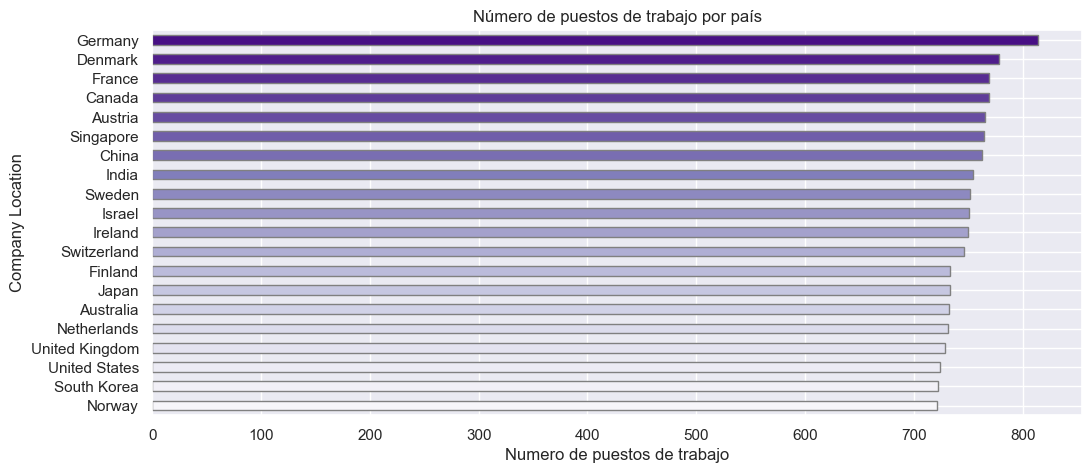

In [28]:
# Numero de puestos publcados por pais de la empresa: donde están localizadas las empresas que contratan
colors = sns.color_palette('Purples', n_colors=20)
ai_jobs.groupby('company_location')['job_title'].count().sort_values(ascending=True).plot.barh(figsize=(12,5), color=colors, edgecolor='gray')

plt.title('Número de puestos de trabajo por país')
plt.xlabel('Numero de puestos de trabajo')
plt.ylabel('Company Location')
plt.show()

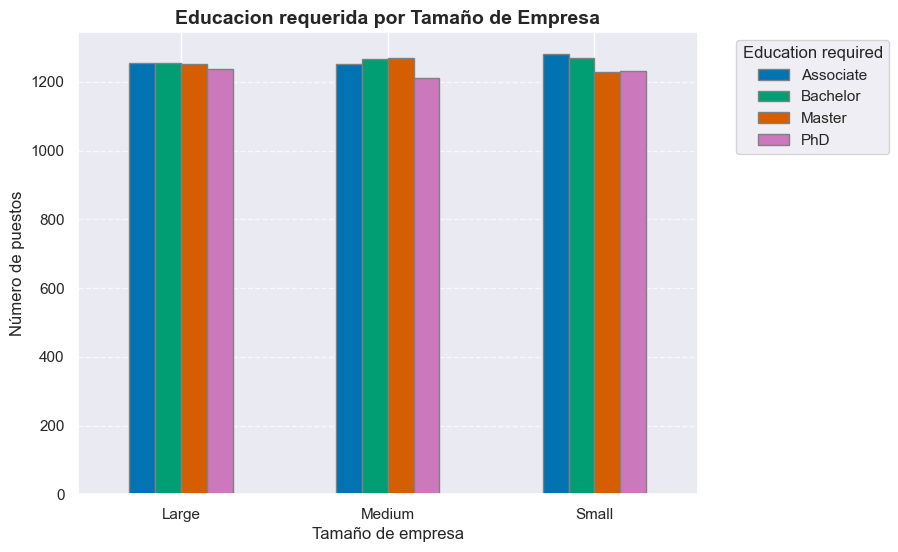

In [29]:
# nivel de experiencia para los puestos segun el tipo de empresa: grande, mediana o pequeña
colors= sns.color_palette('colorblind6') # paleta de colores

pd.crosstab(ai_jobs['company_size'], ai_jobs['education_required']).plot.bar(figsize=(8,6), color=colors, edgecolor='gray') 

plt.xticks(rotation=0)

plt.grid(axis='y', linestyle='--', alpha=0.7) 
plt.title('Educacion requerida por Tamaño de Empresa', fontsize=14, fontweight='bold')
plt.xlabel('Tamaño de empresa')
plt.ylabel('Número de puestos')
plt.legend(title='Education required', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.show()


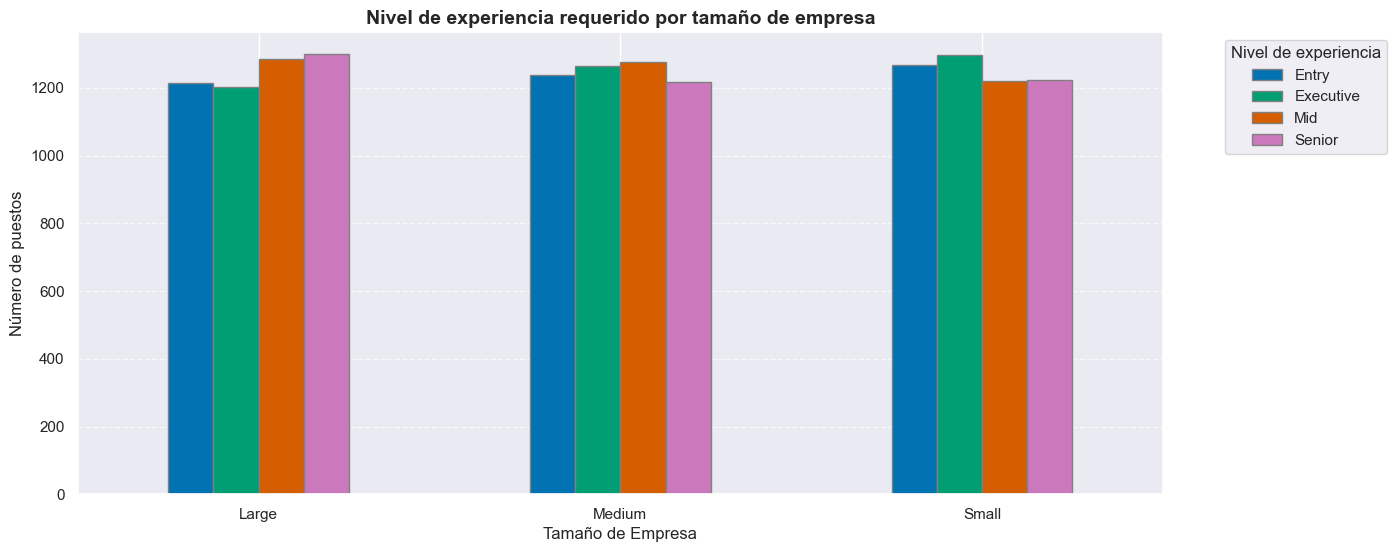

In [30]:
# nivel de experiencia para los puestos segun el tipo de empresa: grande, mediana o pequeña
colors= sns.color_palette('colorblind6') 
pd.crosstab(ai_jobs['company_size'], ai_jobs['experience_level']).plot.bar(figsize=(14,6), color=colors, edgecolor='gray')

plt.xticks(rotation=0)

plt.grid(axis='y', linestyle='--', alpha=0.7) 
plt.title('Nivel de experiencia requerido por tamaño de empresa', fontsize=14, fontweight='bold')
plt.xlabel('Tamaño de Empresa')
plt.ylabel('Número de puestos')
plt.legend(title='Nivel de experiencia', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.show()

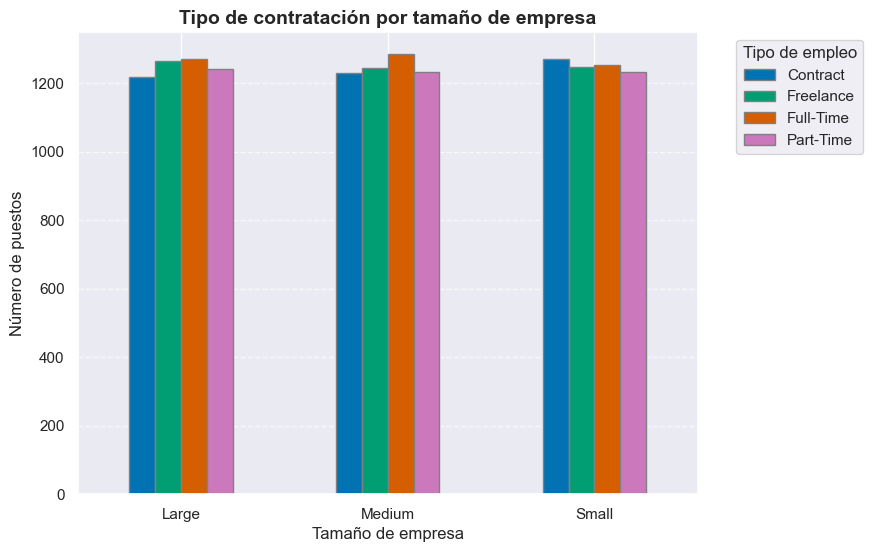

In [31]:
# tipo de empleo ofrecido segun el tipo de empresa: grande, mediana o pequeña
colors= sns.color_palette('colorblind6') 
pd.crosstab(ai_jobs['company_size'], ai_jobs['employment_type']).plot.bar(figsize=(8,6), color=colors, edgecolor='gray') # solo barras
#pd.crosstab(ai_jobs['company_size'], ai_jobs['education_required']).plot.bar(stacked=True, color=colors) 

plt.xticks(rotation=0)

plt.grid(axis='y', linestyle='--', alpha=0.7) 
plt.title('Tipo de contratación por tamaño de empresa', fontsize=14, fontweight='bold')
plt.xlabel('Tamaño de empresa')
plt.ylabel('Número de puestos')
plt.legend(title='Tipo de empleo', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.show()

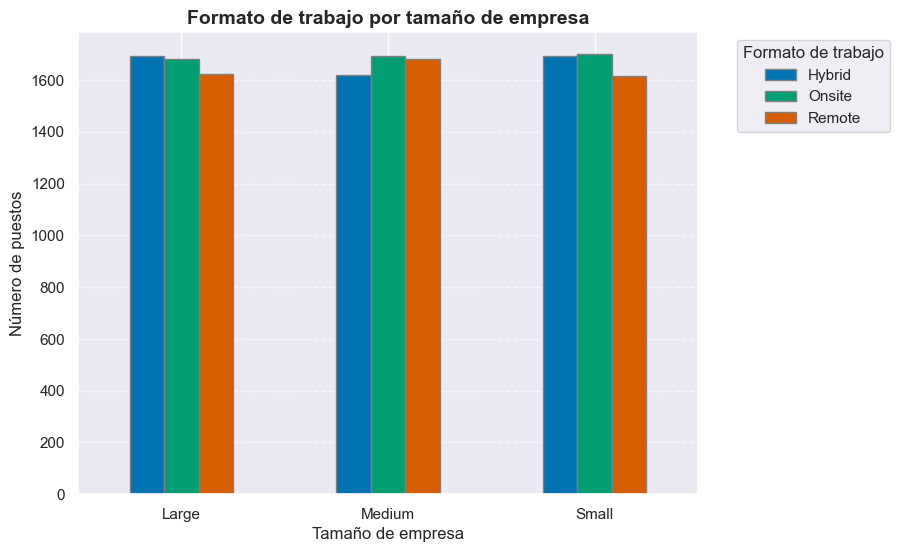

In [32]:
# formato de trabajo ofrecido segun el tipo de empresa: grande, mediana o pequeña
colors= sns.color_palette('colorblind6') # paleta de colores
pd.crosstab(ai_jobs['company_size'], ai_jobs['work_format']).plot.bar(figsize=(8,6), color=colors, edgecolor='gray') # solo barras
#pd.crosstab(ai_jobs['company_size'], ai_jobs['education_required']).plot.bar(stacked=True, color=colors) 

plt.xticks(rotation=0)

plt.grid(axis='y', linestyle='--', alpha=0.7) 
plt.title('Formato de trabajo por tamaño de empresa', fontsize=14, fontweight='bold')
plt.xlabel('Tamaño de empresa')
plt.ylabel('Número de puestos')
plt.legend(title='Formato de trabajo', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.show()

In [33]:
ai_jobs.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15000 entries, 0 to 14999
Data columns (total 23 columns):
 #   Column                Non-Null Count  Dtype         
---  ------                --------------  -----         
 0   job_id                15000 non-null  object        
 1   job_title             15000 non-null  object        
 2   salary_usd            15000 non-null  int64         
 3   experience_level      15000 non-null  object        
 4   employment_type       15000 non-null  object        
 5   company_location      15000 non-null  object        
 6   company_size          15000 non-null  object        
 7   employee_residence    15000 non-null  object        
 8   work_format           15000 non-null  object        
 9   required_skills       15000 non-null  object        
 10  education_required    15000 non-null  object        
 11  years_experience      15000 non-null  int64         
 12  industry              15000 non-null  object        
 13  posting_date    

In [34]:
pd.crosstab(ai_jobs.industry, ai_jobs["experience_level"])

experience_level,Entry,Executive,Mid,Senior
industry,,,,
Automotive,275,243,249,253
Consulting,245,274,246,255
Education,228,241,257,230
Energy,229,265,258,224
Finance,245,247,249,243
Gaming,267,234,245,221
Government,227,248,271,252
Healthcare,252,257,250,238
Manufacturing,242,236,211,273


In [35]:
# Que nivel de experiencia es el mas demandado para los puestos publicados en cada industria
# Dataframe para hacer un heatmap
experience_industry_df = ai_jobs.groupby(['industry','experience_level']).size().unstack(fill_value=0)
#experience_industry_df = pd.crosstab(ai_jobs.industry, ai_jobs["experience_level"])
experience_industry_df

experience_level,Entry,Executive,Mid,Senior
industry,,,,
Automotive,275,243,249,253
Consulting,245,274,246,255
Education,228,241,257,230
Energy,229,265,258,224
Finance,245,247,249,243
Gaming,267,234,245,221
Government,227,248,271,252
Healthcare,252,257,250,238
Manufacturing,242,236,211,273


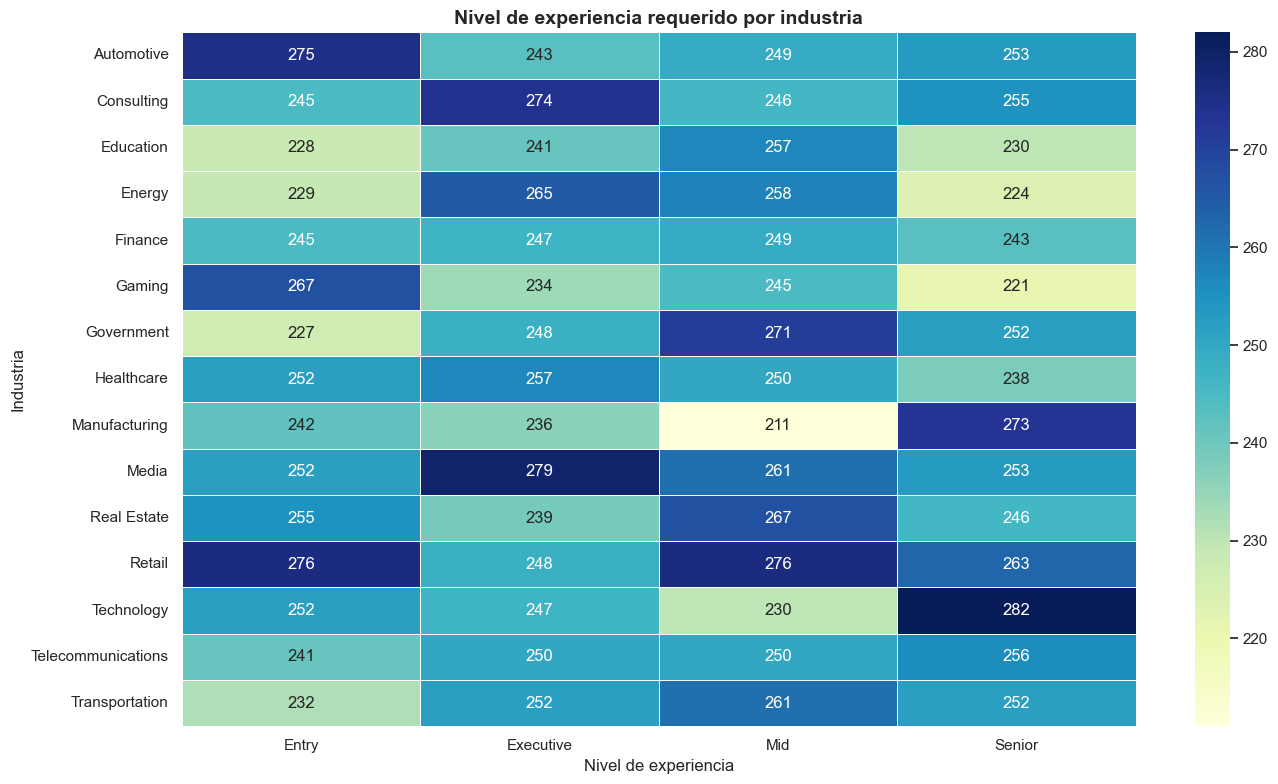

In [36]:

# Heatmap
plt.figure(figsize=(14, 8))
sns.heatmap(experience_industry_df, annot=True, fmt='d', cmap='YlGnBu', linewidths=.5)
plt.title('Nivel de experiencia requerido por industria', fontsize=14, fontweight='bold')
plt.xlabel('Nivel de experiencia')
plt.ylabel('Industria')
plt.xticks(rotation=0)
plt.yticks(rotation=0)
plt.tight_layout()

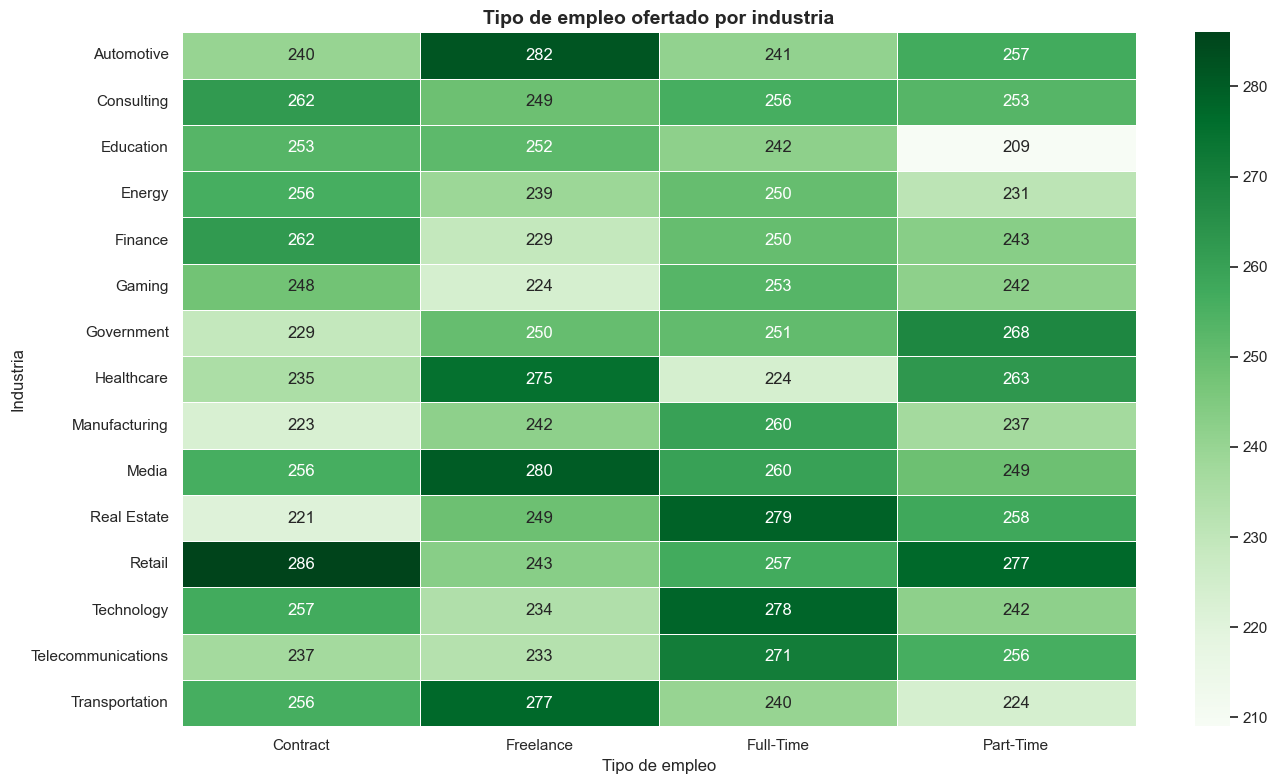

In [37]:
# Que tipo de empleo es el mas ofrecido en cada industria
# Dataframe para hacer un heatmap
industry_employment_type = ai_jobs.groupby(['industry', 'employment_type']).size().unstack(fill_value=0)

# Heatmap
plt.figure(figsize=(14, 8))
sns.heatmap(industry_employment_type, annot=True, fmt='d', cmap='Greens', linewidths=.5)
plt.title('Tipo de empleo ofertado por industria', fontsize=14, fontweight='bold')
plt.xlabel('Tipo de empleo')
plt.ylabel('Industria')
plt.xticks(rotation=0)
plt.yticks(rotation=0)
plt.tight_layout()

In [38]:
industry_workformat = ai_jobs.groupby(['industry', 'work_format']).size().unstack(fill_value=0)
#industry_workformat = industry_workformat.reset_index()
industry_workformat


work_format,Hybrid,Onsite,Remote
industry,,,
Automotive,352,345,323
Consulting,354,335,331
Education,297,342,317
Energy,332,335,309
Finance,332,318,334
Gaming,324,327,316
Government,316,346,336
Healthcare,339,336,322
Manufacturing,329,323,310


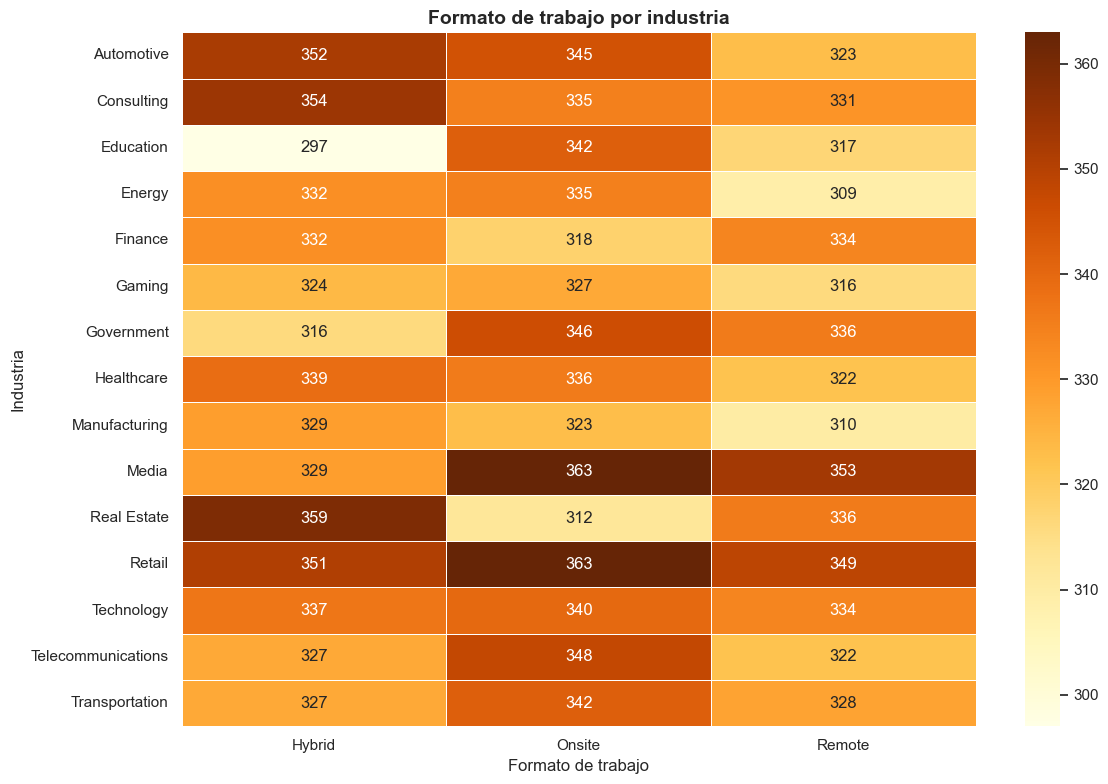

In [39]:
# Que formato de trabajo es el mas ofrecido en cada industria

industry_workformat = ai_jobs.groupby(['industry', 'work_format']).size().unstack(fill_value=0)
#industry_workformat = pd.crosstab(ai_jobs.industry, ai_jobs['work_format'])

# Heatmap
plt.figure(figsize=(12, 8))
sns.heatmap(industry_workformat, annot=True, fmt='d', cmap='YlOrBr', linewidths=.5)
plt.title('Formato de trabajo por industria', fontsize=14, fontweight='bold')
plt.xlabel('Formato de trabajo')
plt.ylabel('Industria')
plt.xticks(rotation=0)
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

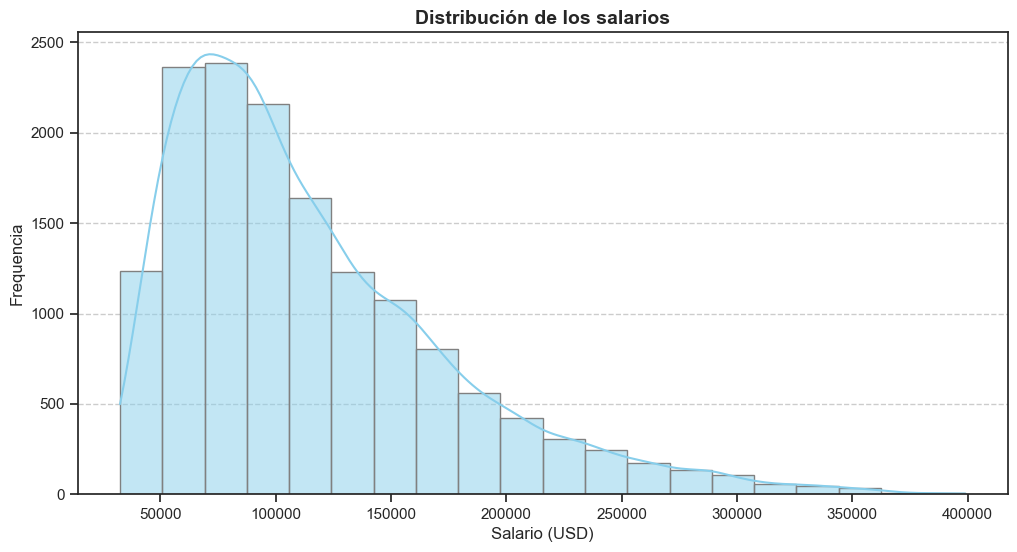

In [40]:
# Distribucion de los salarios a nivel general
#ai_jobs['salary_usd'].plot.hist(bins=20, kde=True, color= 'skyblue', edgecolor='grey')

plt.figure(figsize=(12, 6))
sns.set_style("ticks")

sns.histplot(ai_jobs['salary_usd'],bins=20, kde=True, color= 'skyblue', edgecolor='grey')

plt.grid(axis='y',linestyle= '--')

plt.title("Distribución de los salarios", fontsize=14, fontweight='bold')
plt.xlabel("Salario (USD)")
plt.ylabel("Frequencia")
plt.show()

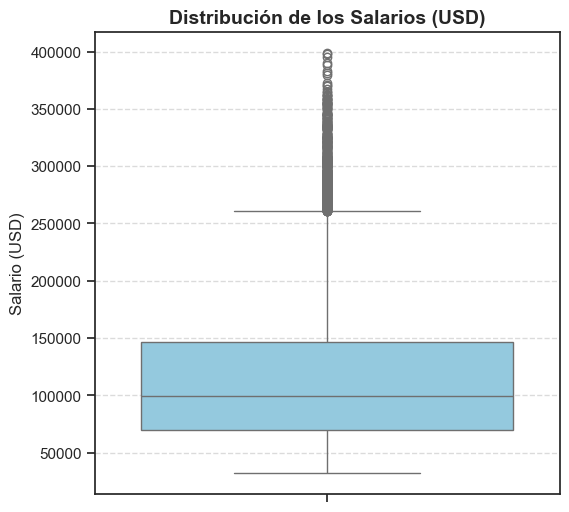

In [41]:
plt.figure(figsize=(6, 6))
sns.boxplot(y='salary_usd', data=ai_jobs,color='skyblue')

plt.grid(axis='y', linestyle='--', alpha=0.7) # Añadir grid suave
plt.xlabel('')
plt.ylabel('Salario (USD)')
plt.title('Distribución de los Salarios (USD)', fontsize=14, fontweight='bold')
plt.xticks(rotation=0) # Rotate x-axis labels if they overlap
plt.show()

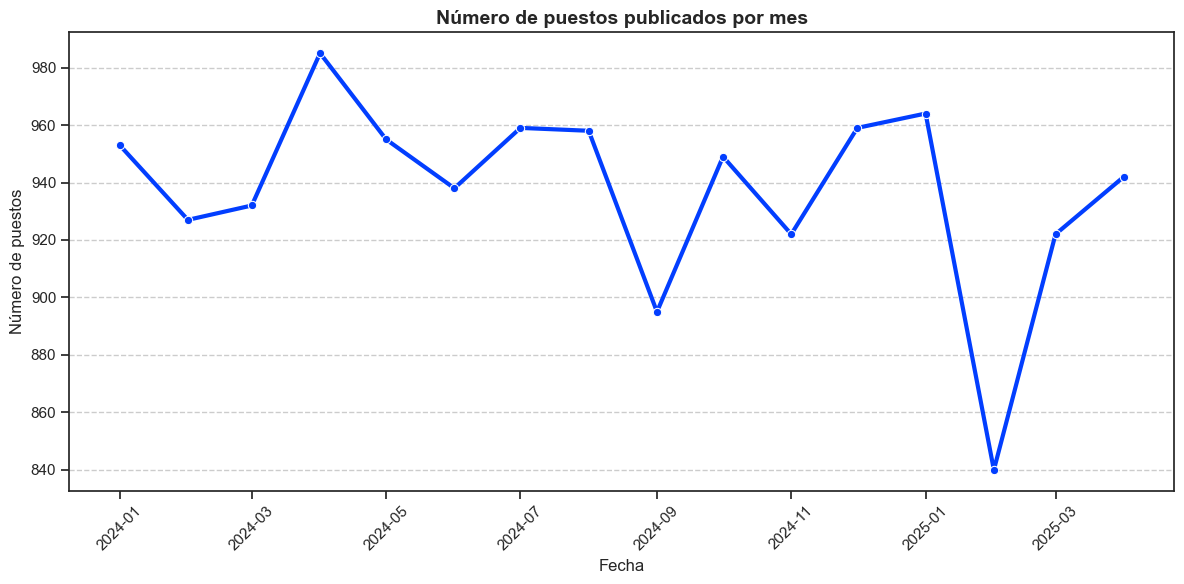

In [42]:
# Contar job postings por mes
monthly_counts = ai_jobs.groupby('month_year').size().reset_index(name='count')

# Configurar el estilo del gráfico
plt.figure(figsize=(12, 6))
sns.set_style("ticks")

sns.lineplot(
    data=monthly_counts, 
    x='month_year', 
    y='count',
    marker='o',
    linewidth=3  # Valor para ajustar el grosor
)

plt.title('Número de puestos publicados por mes', fontsize=14, fontweight='bold')
plt.xlabel('Fecha', fontsize=12)
plt.ylabel('Número de puestos', fontsize=12)
plt.grid(axis='y',linestyle= '--')

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

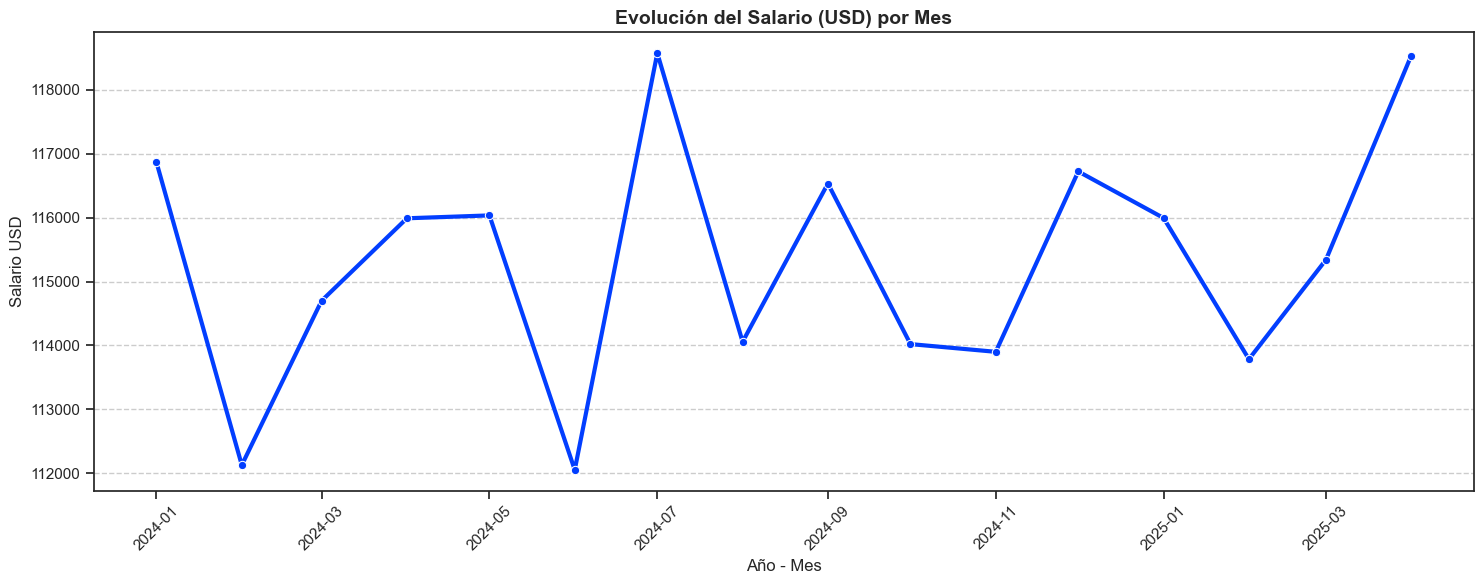

In [43]:
salary_month = ai_jobs.groupby(['posting_year', 'posting_month', 'month_year'])['salary_usd'].mean().reset_index()

# Ordenar por año y mes
salary_month = salary_month.sort_values(['posting_year', 'posting_month'])

# Configurar el estilo del gráfico
plt.figure(figsize=(15, 6))
sns.set_style("ticks")

sns.lineplot(data=salary_month, 
            x='month_year', 
            y='salary_usd',
            marker='o',
            linewidth=3)

plt.title('Evolución del Salario (USD) por Mes', fontsize=14, fontweight='bold')
plt.xlabel('Año - Mes', fontsize=12)
plt.ylabel('Salario USD', fontsize=12)
plt.grid(axis='y',linestyle= '--')

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

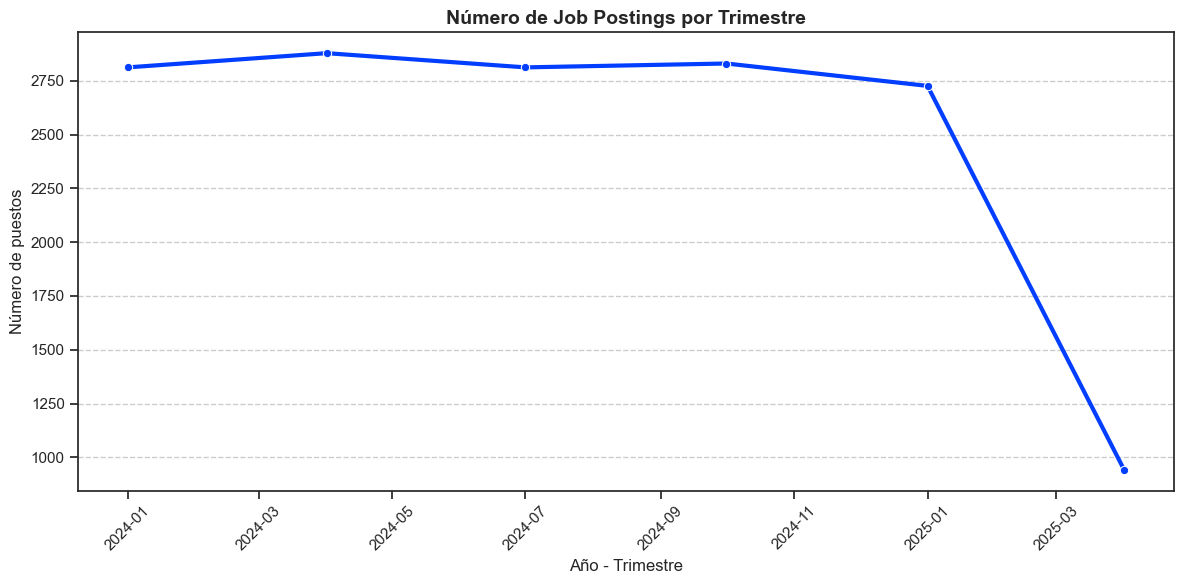

In [44]:
# Contar postings por trimestre
quarterly_counts = ai_jobs.groupby(['posting_year', 'posting_quarter', 'year_quarter'])\
    .size()\
    .reset_index(name='count')

# Ordenar por año y trimestre
quarterly_counts = quarterly_counts.sort_values(['posting_year', 'posting_quarter'])

plt.figure(figsize=(12, 6))
sns.set_style("ticks")

sns.lineplot(data=quarterly_counts, 
            x='year_quarter', 
            y='count',
            marker='o',
            linewidth=3)

plt.title('Número de Job Postings por Trimestre', fontsize=14, fontweight='bold')
plt.xlabel('Año - Trimestre', fontsize=12)
plt.ylabel('Número de puestos', fontsize=12)
plt.grid(axis='y',linestyle= '--')

plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

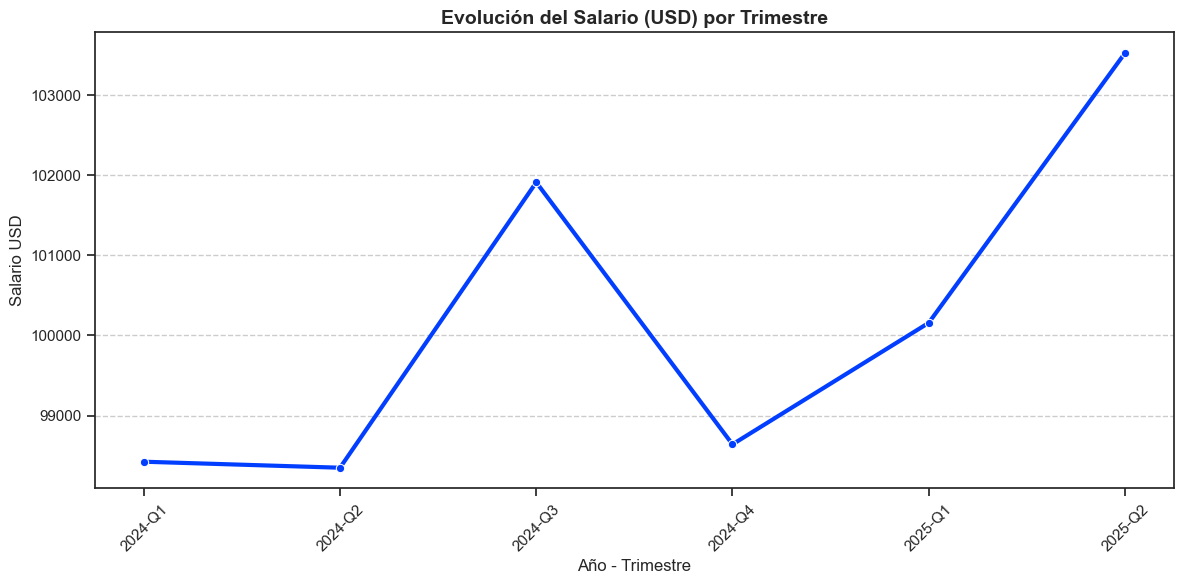

In [45]:
# Calcular el salario medio por trimestre usando salary_usd
salary_over_time = ai_jobs.groupby(['posting_year', 'posting_quarter', 'year_quarter'])['salary_usd'].median().reset_index()

salary_over_time = salary_over_time.sort_values(['posting_year', 'posting_quarter'])  # Ordenar por año y trimestre

salary_over_time['year_quarter_str'] = salary_over_time['posting_year'].astype(str) + '-Q' + salary_over_time['posting_quarter'].astype(str)


# Configurar el estilo del gráfico
plt.figure(figsize=(12, 6))
sns.set_style("ticks")

# Crear el gráfico lineal
sns.lineplot(data=salary_over_time, 
            x='year_quarter_str', 
            y='salary_usd',
            marker='o',
            linewidth=3)

# Personalizar el gráfico
plt.title('Evolución del Salario (USD) por Trimestre', fontsize=14, fontweight='bold')
plt.xlabel('Año - Trimestre', fontsize=12)
plt.ylabel('Salario USD', fontsize=12)
plt.grid(axis='y',linestyle= '--')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

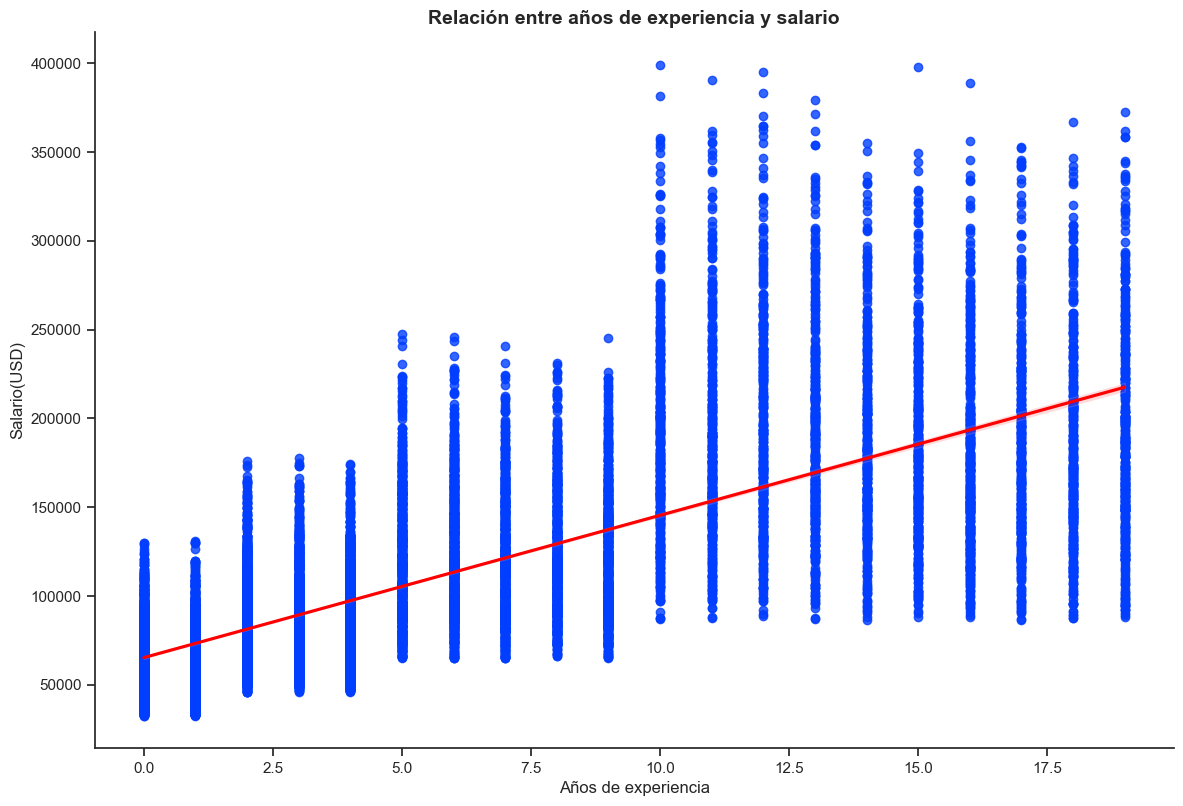

In [46]:
# Relacion entre el salario y los años de experiencia:  salary_usd y years_experience
# Para hacer el gráfico más grande, ajusta el parámetro height y aspect en sns.lmplot.
# Para que la línea de tendencia sea roja, usa line_kws={'color': 'red'}.

sns.lmplot(
    data=ai_jobs,
    x="years_experience",
    y="salary_usd",
    palette='bright',
    height=8,      # altura en pulgadas
    aspect=1.5,    # relación de aspecto (ancho = height * aspect)
    line_kws={'color': 'red'}  # color de la línea de tendencia
)

plt.title('Relación entre años de experiencia y salario', fontsize=14, fontweight='bold')
plt.xlabel('Años de experiencia')
plt.ylabel('Salario(USD)')
plt.show()

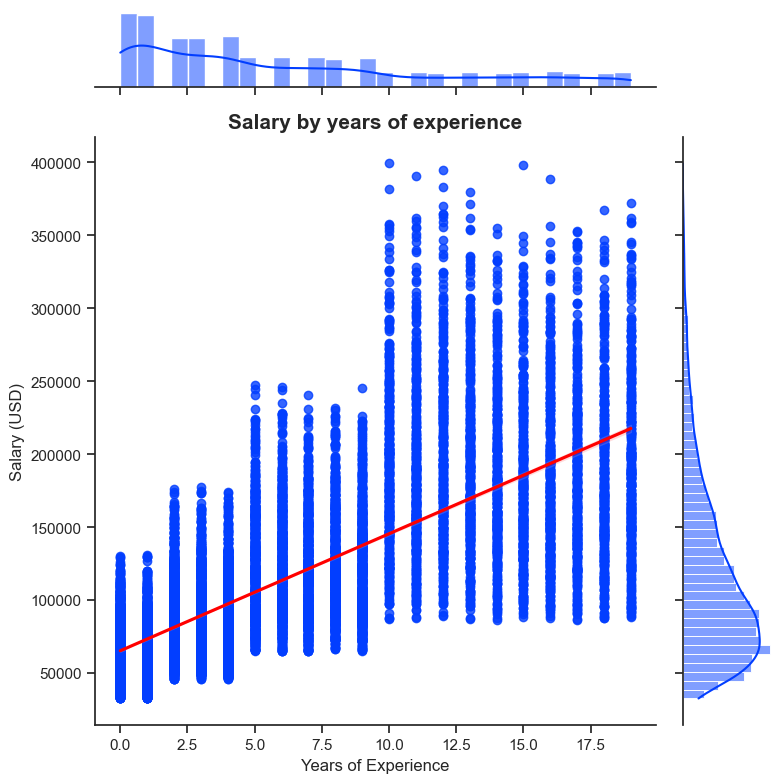

In [47]:
sns.jointplot(
	data=ai_jobs,
	x='years_experience',
	y='salary_usd',
	kind='reg',
    height=8,  # altura en pulgadas  
	palette='bright',      
    line_kws={'color': 'red'}  
)
plt.title("Salary by years of experience", fontsize=15, fontweight='bold')
plt.xlabel("Years of Experience", fontsize=12)
plt.ylabel("Salary (USD)", fontsize=12)
plt.tight_layout()
plt.show()

In [48]:
corr_matrix = ai_jobs[['salary_usd', 'years_experience', 'benefits_score']].corr()
corr_matrix

,salary_usd,years_experience,benefits_score
salary_usd,1.000000,0.737556,0.000985
years_experience,0.737556,1.000000,-0.007275
benefits_score,0.000985,-0.007275,1.000000


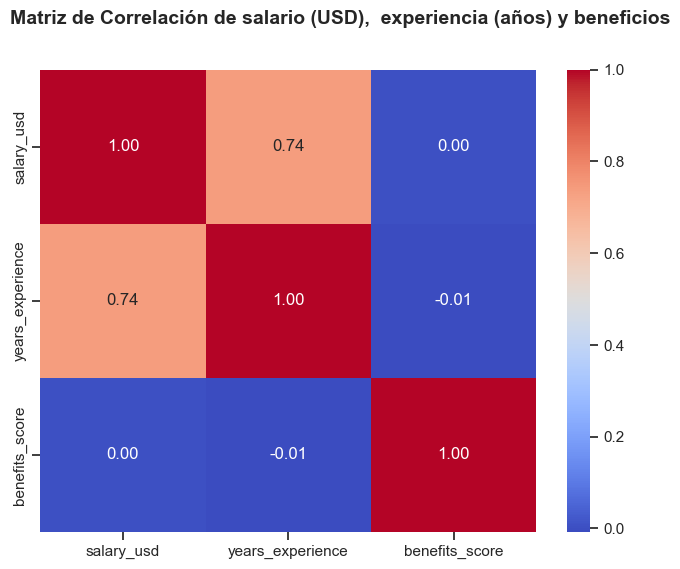

In [49]:
ai_jobs[['salary_usd', 'years_experience', 'benefits_score']].corr()

# Calcular la matriz de correlacion
corr_matrix = ai_jobs[['salary_usd', 'years_experience', 'benefits_score']].corr()

# Crear el mapa de calor
plt.figure(figsize = (8,6))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.suptitle("Matriz de Correlación de salario (USD),  experiencia (años) y beneficios", fontsize=14, fontweight='bold')
plt.show()

In [50]:
#Salario medio por tamaño de empresa
salary_company_size = ai_jobs.groupby('company_size')['salary_usd'].median()
salary_company_size


company_size
Large     114564.0
Medium     98122.0
Small      89648.0
Name: salary_usd, dtype: float64

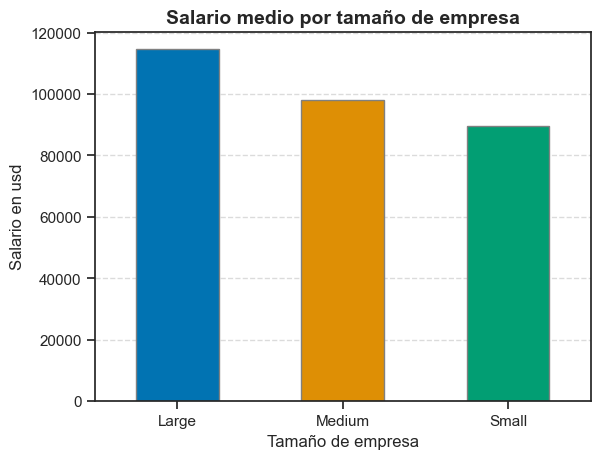

In [51]:
colors= sns.color_palette("colorblind")
salary_company_size.plot.bar(color= colors, edgecolor='grey')

plt.xticks(rotation=0)

plt.grid(axis='y', linestyle='--', alpha=0.7) 
plt.title('Salario medio por tamaño de empresa', fontsize=14, fontweight='bold')
plt.xlabel('Tamaño de empresa')
plt.ylabel('Salario en usd')
plt.show()

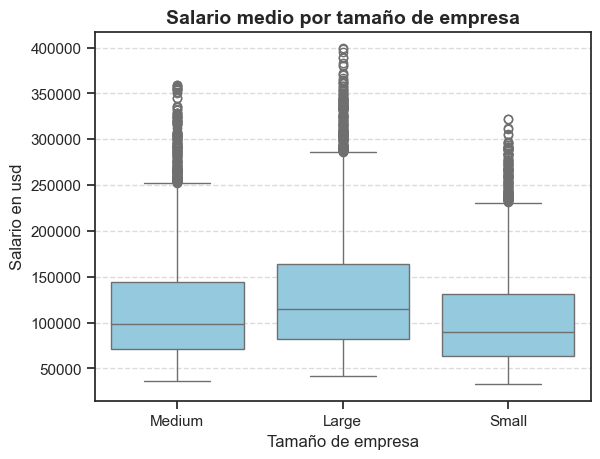

In [52]:
#sns.color_palette('pastel')
sns.boxplot(data = ai_jobs, x = "company_size", y = "salary_usd", color = "skyblue")

plt.grid(axis='y', linestyle='--', alpha=0.7) 
plt.title('Salario medio por tamaño de empresa', fontsize=14, fontweight='bold')
plt.xlabel('Tamaño de empresa')
plt.ylabel('Salario en usd')
plt.show()

In [53]:
#Salario medio por pais donde se encuentra las empresas contratantes
salary_country = ai_jobs.groupby('company_location')['salary_usd'].median().sort_values(ascending=True)
salary_country

company_location
Ireland            73939.5
Austria            74005.0
India              76035.0
South Korea        76244.5
China              76543.0
Israel             78614.0
Japan              79484.0
Finland            80143.0
Canada            100392.0
France            101908.0
Australia         103205.5
Germany           106923.0
Sweden            109435.0
Netherlands       112202.0
Singapore         115122.0
United Kingdom    115281.0
United States     128606.0
Norway            142386.0
Denmark           147504.5
Switzerland       152901.0
Name: salary_usd, dtype: float64

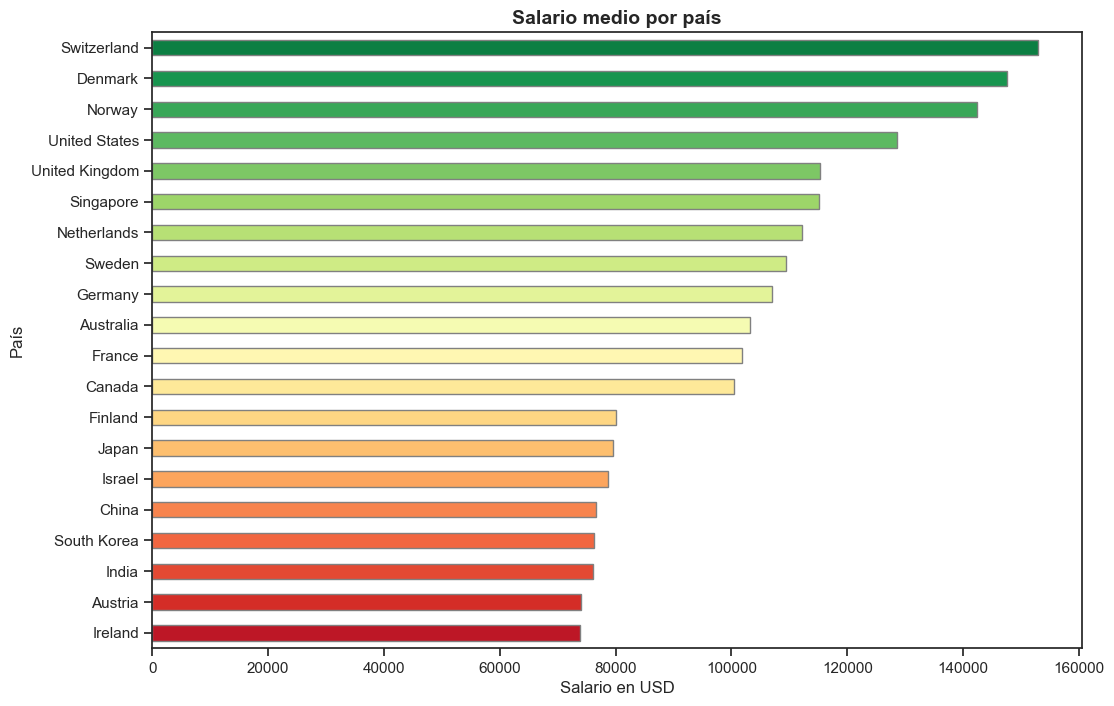

In [54]:
plt.figure(figsize=(12, 8))
colors= sns.color_palette('RdYlGn', n_colors=20)   # pongo paleta de colores
salary_country.plot.barh(color= colors, edgecolor='grey')

plt.xticks(rotation=0)

plt.title('Salario medio por país', fontsize=14, fontweight='bold')
plt.xlabel('Salario en USD')
plt.ylabel('País')
plt.show()

In [55]:
#Salario medio por industria
avg_salary_industry = ai_jobs.groupby('industry')['salary_usd'].median().sort_values(ascending=True)
avg_salary_industry

industry
Gaming                 96073.0
Automotive             97060.5
Retail                 97938.0
Real Estate            98126.0
Energy                 99057.5
Transportation         99330.0
Technology             99539.0
Manufacturing         100007.0
Media                 100272.0
Consulting            100983.5
Education             101097.5
Healthcare            101402.0
Finance               101409.0
Government            101914.5
Telecommunications    102408.0
Name: salary_usd, dtype: float64

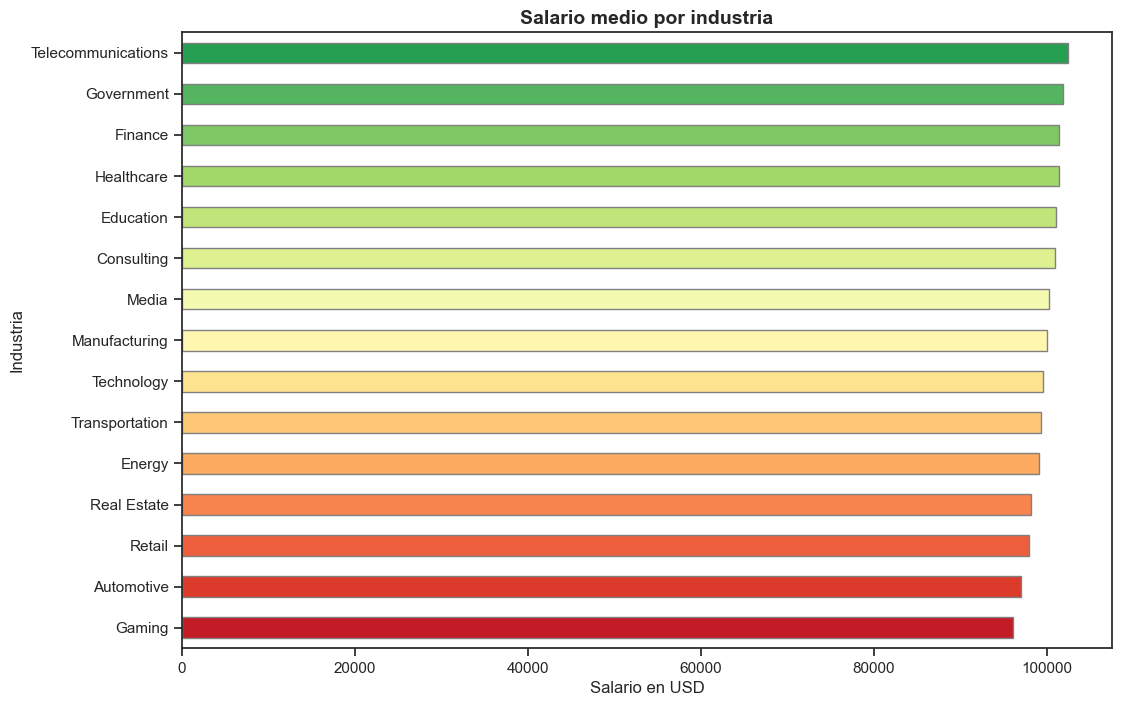

In [56]:
plt.figure(figsize=(12, 8))
colors= sns.color_palette('RdYlGn', n_colors=16)
avg_salary_industry.plot.barh(color= colors, edgecolor='grey')

plt.xticks(rotation=0)

plt.title('Salario medio por industria', fontsize=14, fontweight='bold')
plt.xlabel('Salario en USD')
plt.ylabel('Industria')
plt.show()

In [57]:
#Salario medio por compañias
avg_salary_company = ai_jobs.groupby('company_name')['salary_usd'].median().sort_values(ascending=True)
avg_salary_company

company_name
AI Innovations                 94806.5
Digital Transformation LLC     96465.0
Machine Intelligence Group     96869.0
Advanced Robotics              96976.0
Algorithmic Solutions          98156.0
DataVision Ltd                 98760.0
Smart Analytics                99055.0
DeepTech Ventures              99115.0
Predictive Systems             99617.0
Future Systems                100107.0
Cognitive Computing           100411.5
Quantum Computing Inc         101047.5
Cloud AI Solutions            102474.0
TechCorp Inc                  103209.0
Neural Networks Co            103316.5
Autonomous Tech               103352.0
Name: salary_usd, dtype: float64

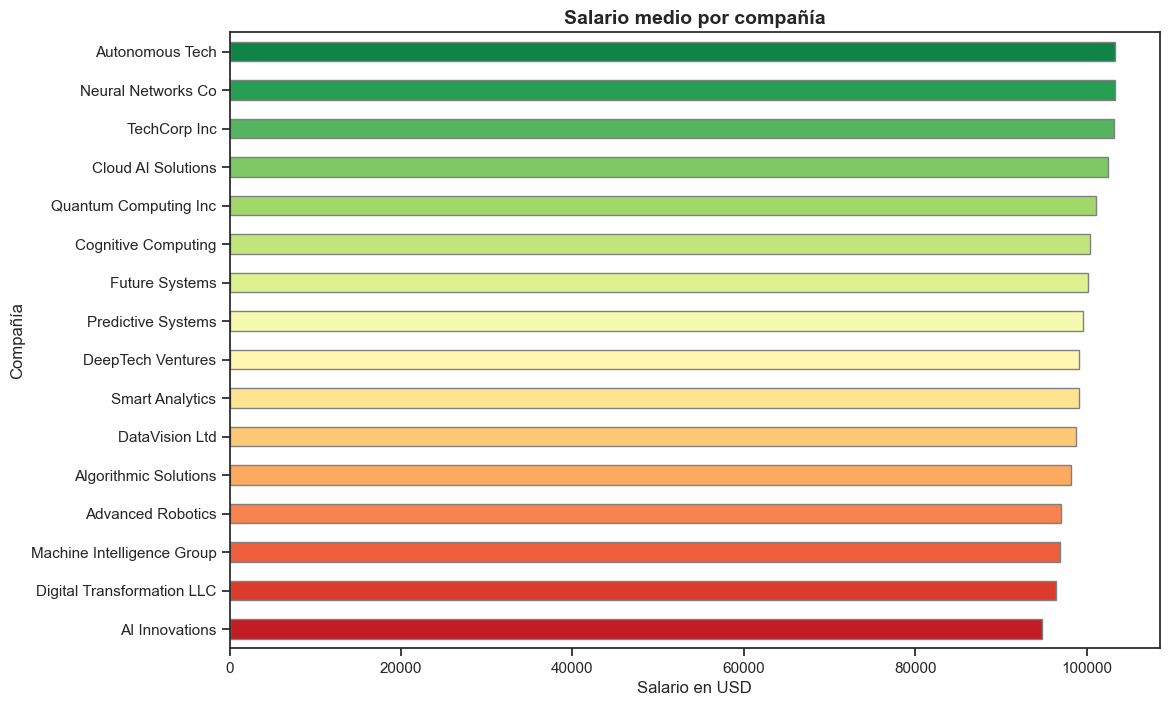

In [58]:
plt.figure(figsize=(12, 8))
colors= sns.color_palette('RdYlGn', n_colors=16)
avg_salary_company.plot.barh(color= colors, edgecolor='grey')

plt.xticks(rotation=0)

plt.title('Salario medio por compañía', fontsize=14, fontweight='bold')
plt.xlabel('Salario en USD')
plt.ylabel('Compañía')
plt.show()

In [59]:
#Salario medio por nivel de experiencia
avg_salary_experience = ai_jobs.groupby('experience_level')['salary_usd'].median().sort_values(ascending=True)
avg_salary_experience

experience_level
Entry         60373.5
Mid           84641.0
Senior       116907.0
Executive    177512.0
Name: salary_usd, dtype: float64

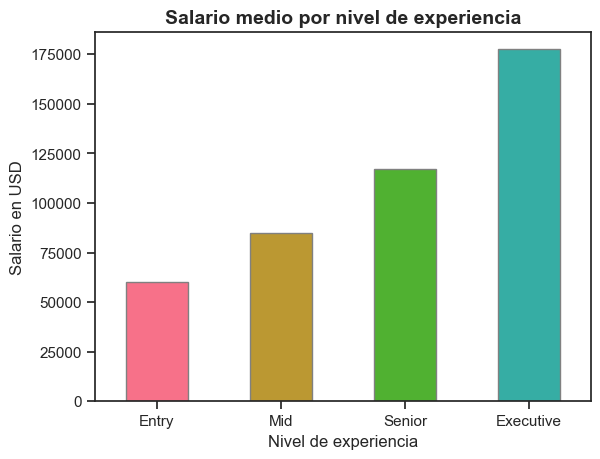

In [60]:
colors= sns.color_palette("husl")   # pongo paleta de colores
avg_salary_experience.plot.bar(color= colors, edgecolor='grey')

plt.xticks(rotation=0)

plt.title('Salario medio por nivel de experiencia', fontsize=14, fontweight='bold')
plt.xlabel('Nivel de experiencia')
plt.ylabel('Salario en USD')
plt.show()

In [61]:
# Salario promedio por industria y nivel de experiencia. Ordenado por entrey level (nuestro nivel)
avg_salary_industry_exp = ai_jobs.groupby(['industry', 'experience_level'])['salary_usd'].median().unstack()
avg_salary_industry_exp = avg_salary_industry_exp.sort_values(by='Entry', ascending=False).head(10)
avg_salary_industry_exp


experience_level,Entry,Executive,Mid,Senior
industry,,,,
Healthcare,62877.5,173242.0,83399.5,119327.5
Education,62201.0,178015.0,83549.0,120391.0
Government,61796.0,177300.0,84641.0,115566.0
Automotive,61762.0,175411.0,84056.0,117262.0
Technology,61509.5,174949.0,84025.0,116852.5
Real Estate,61320.0,183140.0,85157.0,119657.0
Consulting,61291.0,180009.5,83996.0,112978.0
Gaming,60829.0,183389.0,79484.0,121160.0
Manufacturing,60802.0,182620.5,87531.0,114714.0


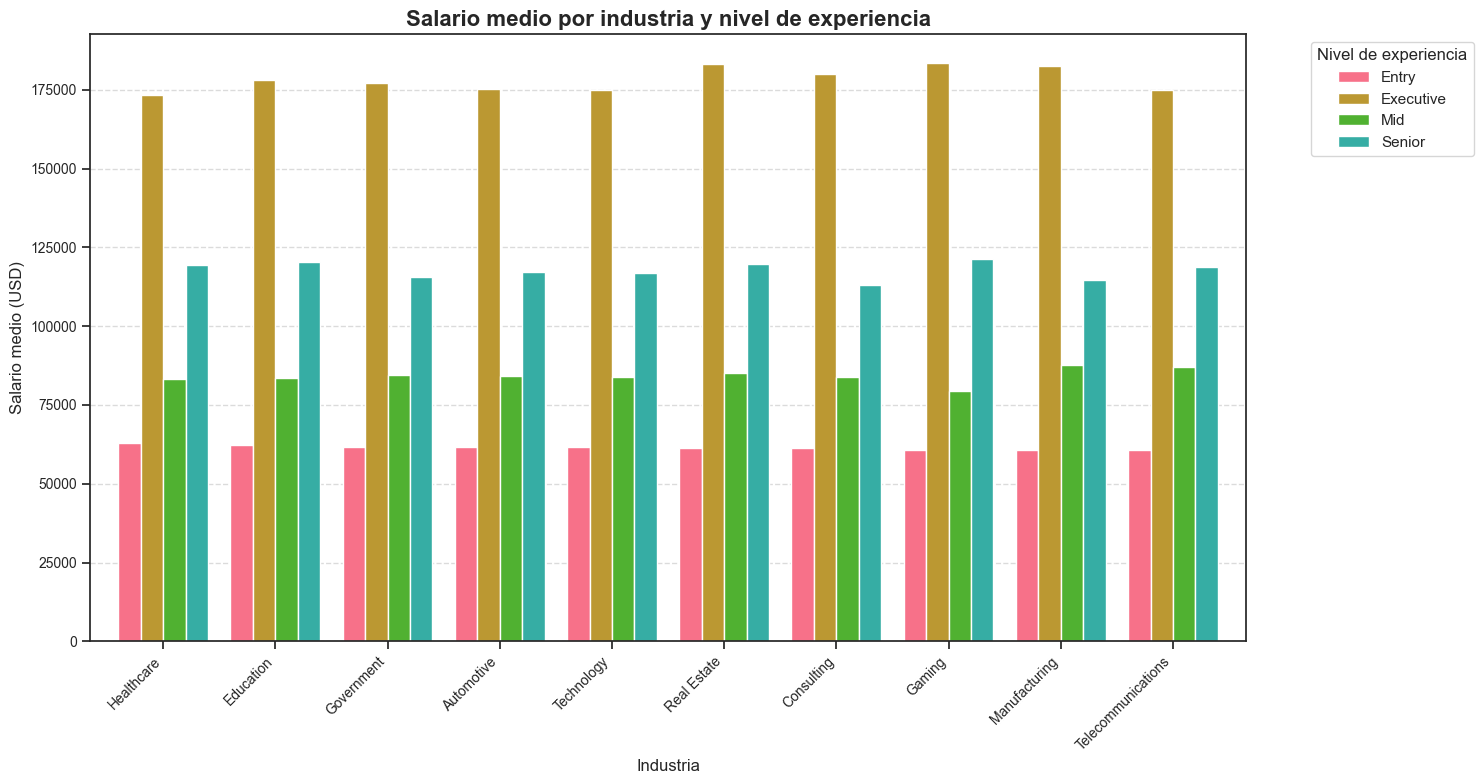

In [62]:
# Salario promedio por industria y nivel de experiencia. Ordenado por Entry level (nuestro nivel)
colors= sns.color_palette("husl")  
avg_salary_industry_exp.plot(kind='bar', figsize=(15, 8), width=0.8, color=colors)

plt.title('Salario medio por industria y nivel de experiencia', fontsize=16, fontweight='bold')
plt.xlabel('Industria', fontsize=12)
plt.ylabel('Salario medio (USD)', fontsize=12)
plt.xticks(rotation=45, ha='right', fontsize=10)
plt.yticks(fontsize=10)
plt.legend(title='Nivel de experiencia', bbox_to_anchor=(1.05, 1), loc='upper left') # Mover leyenda que no se superponga al grafico
plt.grid(axis='y', linestyle='--', alpha=0.7) # Añadir grid suave
plt.tight_layout() # Ajusta automáticamente los parámetros
plt.show()

In [63]:
# Salario promedio por tamaño de empresa y nivel de experiencia. 
avg_salary_size_exp = ai_jobs.groupby(['company_size', 'experience_level'])['salary_usd'].median().unstack()
#avg_salary_size_exp = avg_salary_size_exp.sort_values(by='Entry', ascending=False)
avg_salary_size_exp

experience_level,Entry,Executive,Mid,Senior
company_size,,,,
Large,66455.5,202130.0,95912.5,132794.0
Medium,58559.0,175297.0,82214.0,111606.5
Small,52021.0,155871.0,72761.5,103705.0


<Figure size 1500x800 with 0 Axes>

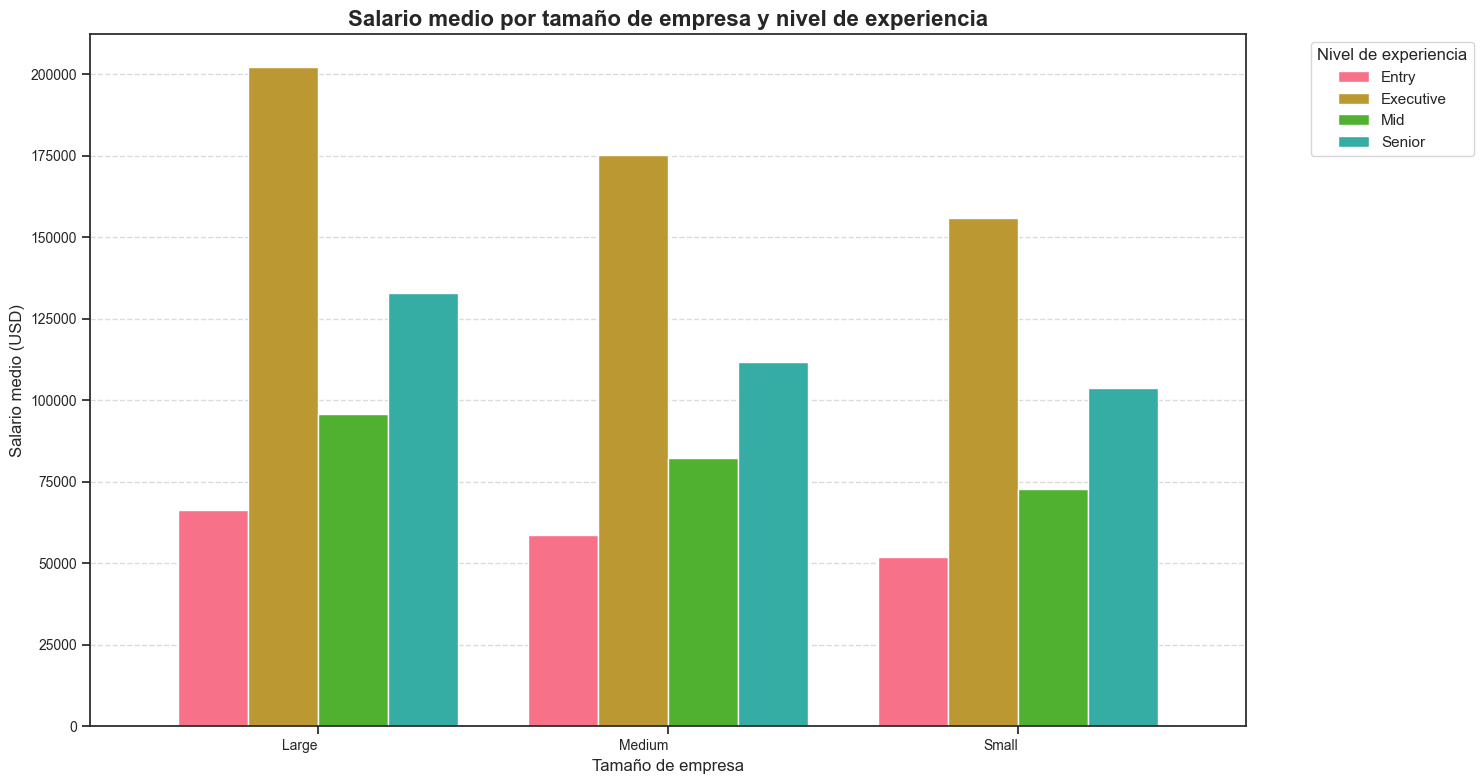

In [64]:
# Salario promedio por tamaño de empresa y nivel de experiencia. Ordenado por Entry level (nuestro nivel)
plt.figure(figsize=(15, 8))
colors= sns.color_palette("husl")  
avg_salary_size_exp.plot(kind='bar', figsize=(15, 8), width=0.8, color=colors)

plt.title('Salario medio por tamaño de empresa y nivel de experiencia', fontsize=16, fontweight='bold')
plt.xlabel('Tamaño de empresa', fontsize=12)
plt.ylabel('Salario medio (USD)', fontsize=12)
plt.xticks(rotation=0, ha='right', fontsize=10)
plt.yticks(fontsize=10)
plt.legend(title='Nivel de experiencia', bbox_to_anchor=(1.05, 1), loc='upper left') # Mover leyenda que no se superponga al grafico
plt.grid(axis='y', linestyle='--', alpha=0.7) # Añadir grid suave
plt.tight_layout() # Ajusta automáticamente los parámetros
plt.show()

In [65]:
# Salario promedio por area de trabajo y nivel de experiencia. 
avg_salary_area_exp = ai_jobs.groupby(['job_area', 'experience_level'])['salary_usd'].median().unstack()
#avg_salary_area_exp = avg_salary_size_exp.sort_values(by='Entry', ascending=False)
avg_salary_area_exp

experience_level,Entry,Executive,Mid,Senior
job_area,,,,
AI Model Development & Engineering,60774.0,178695.0,83390.0,116430.0
Data & Infrastructure,60578.0,176004.0,85476.5,116611.0
Operations & Maintenance (MLOps),60097.0,172671.0,84350.0,116684.5
Strategy & Business Application,59483.0,179157.0,85908.0,118570.0


<Figure size 1500x800 with 0 Axes>

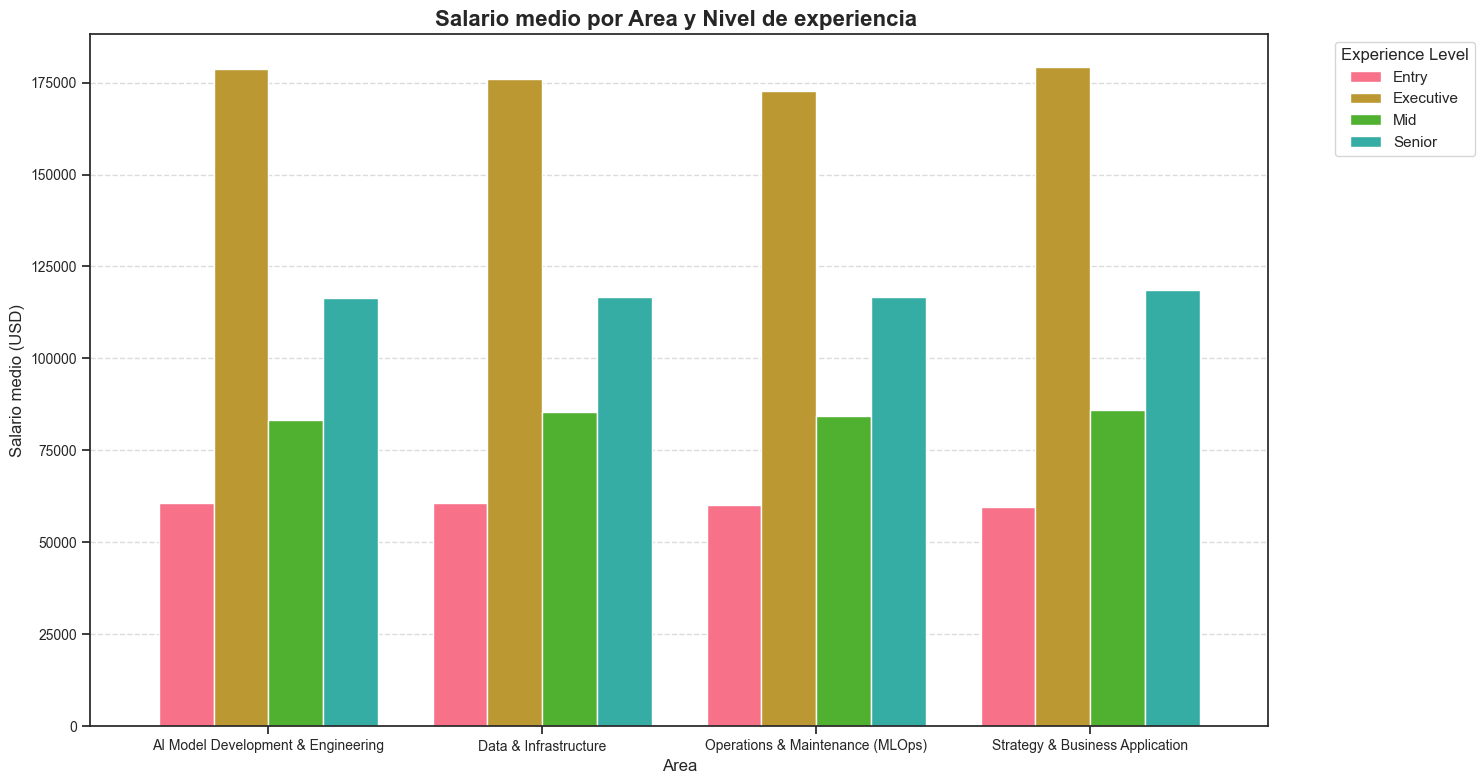

In [66]:
# Salario promedio por area tecnica y nivel de experiencia. 
plt.figure(figsize=(15, 8))
colors= sns.color_palette("husl")

avg_salary_area_exp.plot(kind='bar', figsize=(15, 8), width=0.8, color=colors)

plt.title('Salario medio por Area y Nivel de experiencia ', fontsize=16, fontweight='bold')
plt.xlabel('Area', fontsize=12)
plt.ylabel('Salario medio (USD)', fontsize=12)
plt.xticks(rotation=0, ha='center', fontsize=10)
plt.yticks(fontsize=10)
plt.legend(title='Experience Level', bbox_to_anchor=(1.05, 1), loc='upper left') # Mover leyenda que no se superponga al grafico
plt.grid(axis='y', linestyle='--', alpha=0.7) 
plt.tight_layout()
plt.show()

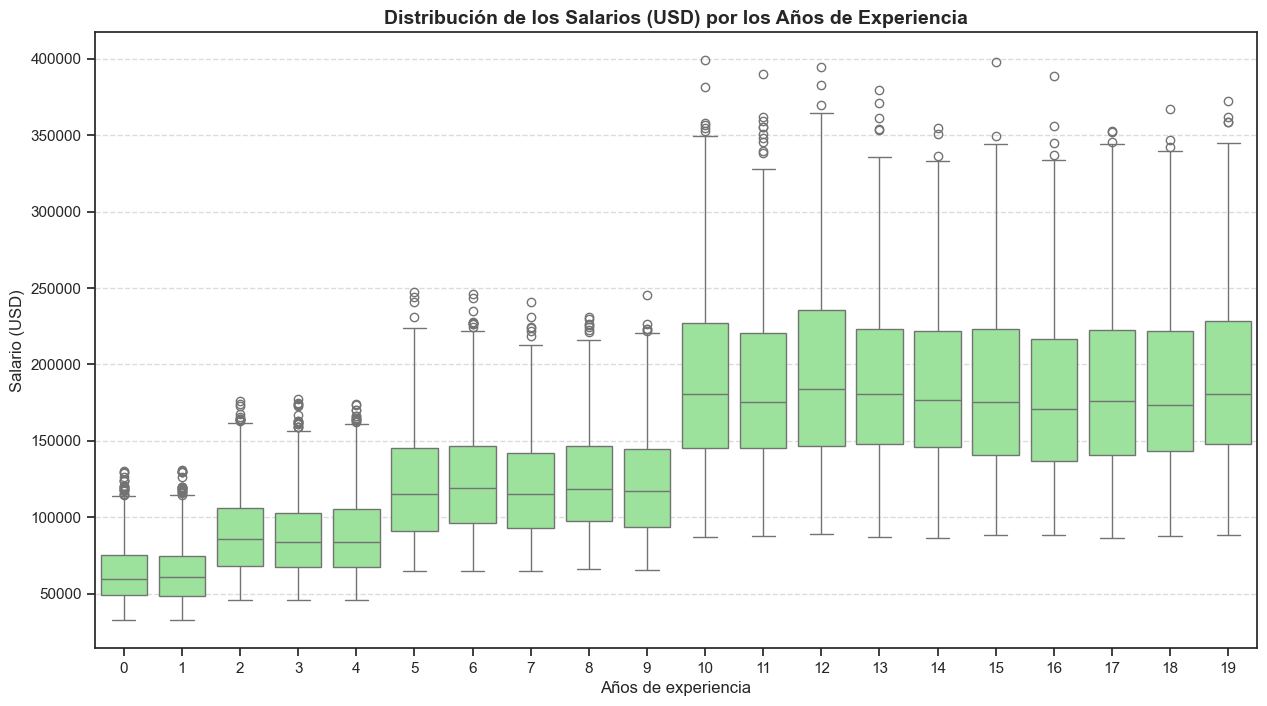

In [67]:
plt.figure(figsize=(15, 8))
sns.boxplot(x='years_experience', y='salary_usd', data=ai_jobs,color='lightgreen')

plt.grid(axis='y', linestyle='--', alpha=0.7) 
plt.xlabel('Años de experiencia')
plt.ylabel('Salario (USD)')
plt.title('Distribución de los Salarios (USD) por los Años de Experiencia', fontsize=14, fontweight='bold')
plt.xticks(rotation=0) 
plt.show()

In [68]:
#Salario medio por nivel de educacion requerida 
avg_salary_education = ai_jobs.groupby('education_required')['salary_usd'].median().sort_values(ascending=True)
avg_salary_education

education_required
PhD           97171.5
Bachelor      99087.0
Associate     99139.0
Master       102553.5
Name: salary_usd, dtype: float64

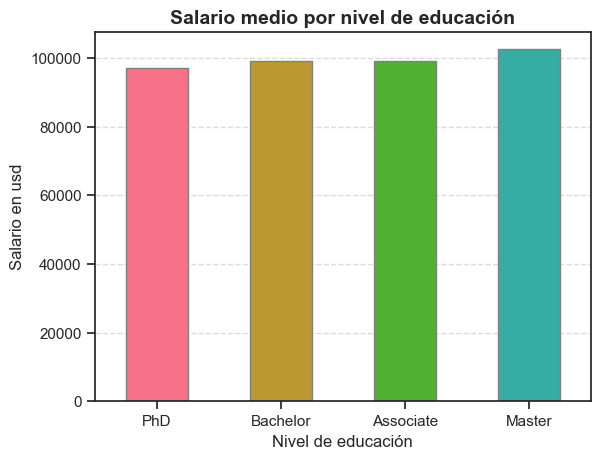

In [69]:
colors= sns.color_palette("husl")   
avg_salary_education.plot.bar(color= colors, edgecolor='grey')

plt.grid(axis='y', linestyle='--', alpha=0.7) 
plt.xticks(rotation=0)

plt.title('Salario medio por nivel de educación', fontsize=14, fontweight='bold')
plt.xlabel('Nivel de educación')
plt.ylabel('Salario en usd')
plt.show()

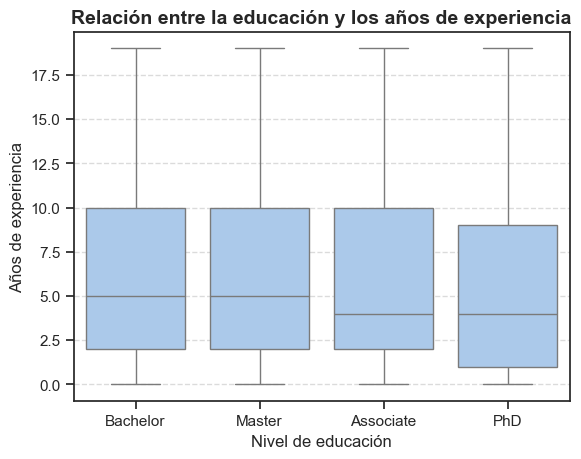

In [70]:
# Relacion entre nivel de experiencia y educacion requerida
sns.set_palette("pastel")
sns.boxplot(data = ai_jobs, x = "education_required", y = "years_experience")

plt.grid(axis='y', linestyle='--', alpha=0.7) 
plt.title('Relación entre la educación y los años de experiencia', fontsize=14, fontweight='bold')
plt.xlabel('Nivel de educación')
plt.ylabel('Años de experiencia')
plt.show()

In [71]:
ai_jobs2= ai_jobs[['job_id','job_title','industry','job_area','company_size','required_skills']]
ai_jobs2['required_skills'] = ai_jobs2['required_skills'].str.split(",")
ai_jobs2 = ai_jobs2.explode('required_skills', ignore_index = True)
ai_jobs2['required_skills'] = ai_jobs2['required_skills'].str.strip()
print(ai_jobs2.shape)
ai_jobs2.head(20)


(59893, 6)


,job_id,job_title,industry,job_area,company_size,required_skills
0,AI00001,AI Research Scientist,Automotive,Strategy & Business Application,Medium,Tableau
1,AI00001,AI Research Scientist,Automotive,Strategy & Business Application,Medium,PyTorch
2,AI00001,AI Research Scientist,Automotive,Strategy & Business Application,Medium,Kubernetes
3,AI00001,AI Research Scientist,Automotive,Strategy & Business Application,Medium,Linux
4,AI00001,AI Research Scientist,Automotive,Strategy & Business Application,Medium,NLP
5,AI00002,AI Software Engineer,Media,AI Model Development & Engineering,Medium,Deep Learning
6,AI00002,AI Software Engineer,Media,AI Model Development & Engineering,Medium,AWS
7,AI00002,AI Software Engineer,Media,AI Model Development & Engineering,Medium,Mathematics
8,AI00002,AI Software Engineer,Media,AI Model Development & Engineering,Medium,Python
9,AI00002,AI Software Engineer,Media,AI Model Development & Engineering,Medium,Docker


In [72]:
Skills= ai_jobs2.groupby('required_skills')['job_id'].count().sort_values(ascending=False).reset_index(name='Count')
Skills['Percentage'] = round(Skills['Count'] / 15000,2)
Skills.head(10)

,required_skills,Count,Percentage
0,Python,4450,0.30
1,SQL,3407,0.23
2,TensorFlow,3022,0.20
3,Kubernetes,3009,0.20
4,Scala,2794,0.19
5,PyTorch,2777,0.19
6,Linux,2705,0.18
7,Git,2631,0.18
8,Java,2578,0.17
9,GCP,2442,0.16


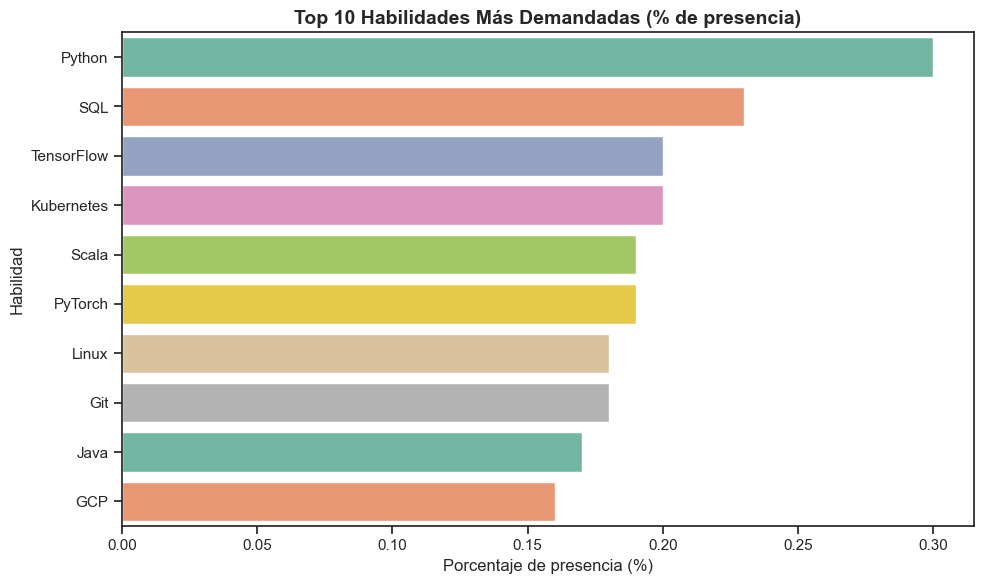

In [73]:
# Gráfico de barras horizontales para mostrar el porcentaje de las 10 habilidades más demandadas
top10_skills = Skills.head(10)
plt.figure(figsize=(10, 6))
sns.barplot(
    data=top10_skills,
    y='required_skills',
    x='Percentage',
    palette='Set2'
)
plt.xlabel('Porcentaje de presencia (%)')
plt.ylabel('Habilidad')
plt.title('Top 10 Habilidades Más Demandadas (% de presencia)',fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

In [74]:
top_skills_comp_size = (
    ai_jobs2.groupby('company_size')['required_skills']
    .value_counts()
    .groupby(level=0, group_keys=False)
    .nlargest(10)
    .reset_index(name='Count')
)
top_skills_comp_size


,company_size,required_skills,Count
0,Large,Python,1475
1,Large,SQL,1129
2,Large,TensorFlow,1000
3,Large,Kubernetes,996
4,Large,Scala,948
5,Large,Git,922
6,Large,Java,895
7,Large,PyTorch,893
8,Large,Linux,882
9,Large,Hadoop,819


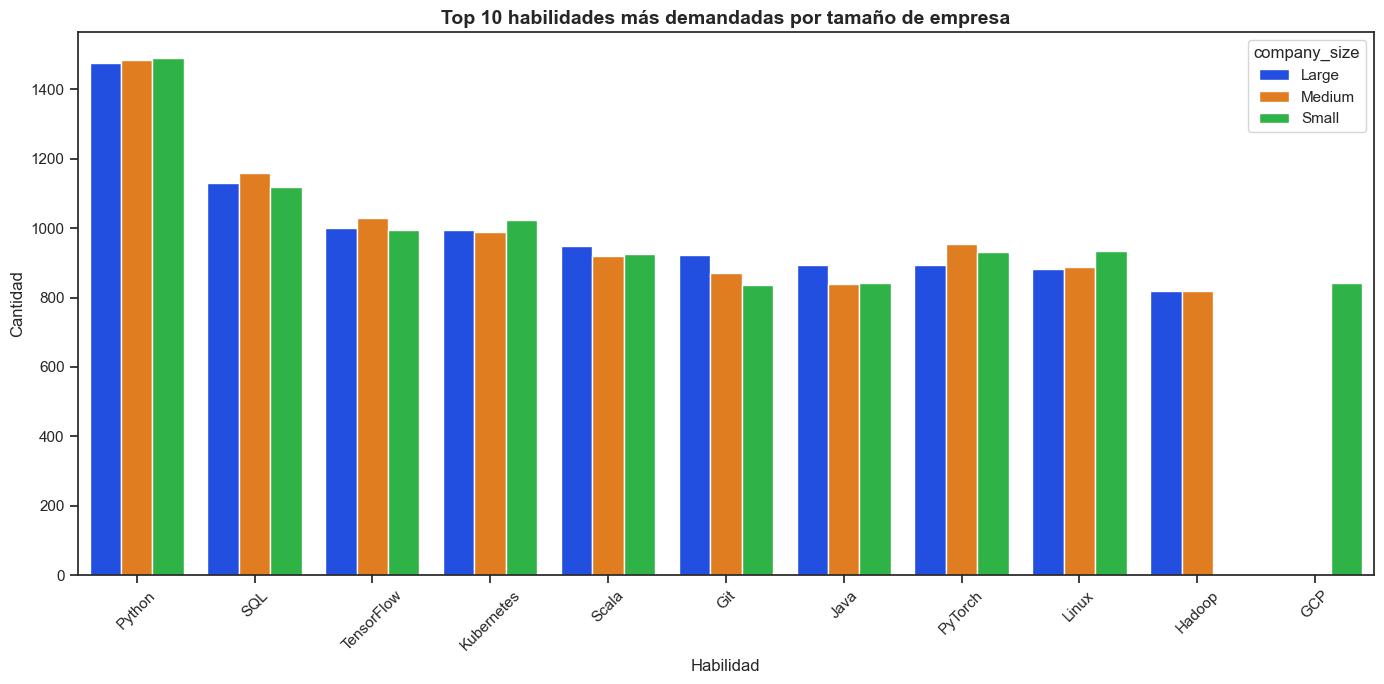

In [75]:
plt.figure(figsize=(14, 7))
sns.barplot(
    data=top_skills_comp_size,
    x='required_skills',
    y='Count',
    hue='company_size',
    palette='bright'
)
plt.title('Top 10 habilidades más demandadas por tamaño de empresa',fontsize=14, fontweight='bold')
plt.xlabel('Habilidad')
plt.ylabel('Cantidad')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()